# Smart Parking — Component Benchmark

Test từng thành phần AI riêng biệt, đo latency / accuracy / throughput.

### Components:
1. **PlateDetector** — YOLOv8n plate detection (data riêng)
2. **PlateOCRYolo + Validator** — YOLOv8n character recognition (data riêng, YOLO labels)
3. **FaceEngine** — InsightFace detection + embedding (LFW dataset)
4. **ParkingDB** — pgvector cosine search (dùng embedding thật từ LFW)
5. **End-to-End Pipeline** — Full flow benchmark

In [1]:
import numpy as np
import cv2
import time
import os
import sys
import glob
import json
import logging
import random
from pathlib import Path
from collections import defaultdict, Counter

%matplotlib inline
import matplotlib
# matplotlib.use('Agg')  # Fix cho Jetson không có display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'font.size': 11,
})

C = {
    'green': '#22c55e', 'blue': '#3b82f6', 'yellow': '#eab308',
    'red': '#ef4444', 'purple': '#a855f7', 'cyan': '#06b6d4',
    'orange': '#f97316', 'pink': '#ec4899',
}

logging.basicConfig(level=logging.WARNING)
print('Imports OK')

Imports OK


In [2]:
PROJECT_DIR = Path('/home/somethink/parking_system')
sys.path.insert(0, str(PROJECT_DIR))

# ── 1) PLATE DETECTION DATA ──
DET_IMAGES_DIR = 'yolo_plate_data/images/val'
DET_LABELS_DIR = 'yolo_plate_data/labels/val'

# ── 2) PLATE RECOGNITION (OCR) DATA ──
OCR_IMAGES_DIR = 'yolo_plate_ocr_data/images/val'
OCR_LABELS_DIR = 'yolo_plate_ocr_data/labels/val'
OCR_TEXT_GT = 'paddle_format/0rec_gt.txt'

# ── 3) FACE DATA — tự download LFW ──
LFW_DIR = str(PROJECT_DIR / 'benchmark_data' / 'lfw_funneled')

# ── Model paths ──
PLATE_MODEL = str(PROJECT_DIR / 'models' / 'plate_yolov8n.engine')
OCR_MODEL = str(PROJECT_DIR / 'models' / 'plate_ocr_yolov8n.engine')

# ── Benchmark params ──
N_WARMUP = 5
N_BENCH  = 100

# ── OCR model params ──
OCR_IMGSZ = 320
OCR_CONF = 0.3
OCR_DEVICE = 0

# ── Validate paths ──
def check_dir(name, path):
    if not path:
        print(f'  ⚠️  {name}: CHƯA SET')
        return False
    p = Path(path)
    if p.is_dir():
        n = len(list(p.iterdir()))
        print(f'  ✅ {name}: {path} ({n} files)')
        return True
    print(f'  ❌ {name}: KHÔNG TỒN TẠI')
    return False

print('Checking paths:')
HAS_DET_IMG = check_dir('Det images', DET_IMAGES_DIR)
HAS_DET_LBL = check_dir('Det labels', DET_LABELS_DIR)
HAS_DET = HAS_DET_IMG and HAS_DET_LBL
HAS_OCR_IMG = check_dir('OCR images', OCR_IMAGES_DIR)
HAS_OCR_LBL = check_dir('OCR labels', OCR_LABELS_DIR)
HAS_OCR = HAS_OCR_IMG and HAS_OCR_LBL
HAS_LFW = check_dir('LFW faces', LFW_DIR)
print(f'  {"✅" if os.path.exists(PLATE_MODEL) else "❌"} Plate model: {PLATE_MODEL}')
print(f'  {"✅" if os.path.exists(OCR_MODEL) else "❌"} OCR model: {OCR_MODEL}')
print(f'  {"✅" if os.path.exists(OCR_TEXT_GT) else "⚠️"} OCR text GT: {OCR_TEXT_GT}')

Checking paths:
  ✅ Det images: yolo_plate_data/images/val (1651 files)
  ✅ Det labels: yolo_plate_data/labels/val (1651 files)
  ✅ OCR images: yolo_plate_ocr_data/images/val (450 files)
  ✅ OCR labels: yolo_plate_ocr_data/labels/val (450 files)
  ✅ LFW faces: /home/somethink/parking_system/benchmark_data/lfw_funneled (5751 files)
  ✅ Plate model: /home/somethink/parking_system/models/plate_yolov8n.engine
  ✅ OCR model: /home/somethink/parking_system/models/plate_ocr_yolov8n.engine
  ✅ OCR text GT: paddle_format/0rec_gt.txt


In [3]:
def bench(func, n=N_BENCH, warmup=N_WARMUP, label=''):
    """Benchmark 1 function → dict latency stats."""
    for _ in range(warmup):
        func()
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func()
        times.append((time.perf_counter() - t0) * 1000)
    arr = np.array(times)
    s = {
        'label': label, 'n': n,
        'mean': arr.mean(), 'std': arr.std(),
        'min': arr.min(), 'max': arr.max(),
        'p50': np.percentile(arr, 50),
        'p95': np.percentile(arr, 95),
        'p99': np.percentile(arr, 99),
        'fps': 1000.0 / arr.mean() if arr.mean() > 0 else 0,
        'raw': arr,
    }
    print(f'  {label:30s}  avg={s["mean"]:7.2f}ms  '
          f'p95={s["p95"]:7.2f}ms  fps={s["fps"]:6.1f}')
    return s

def iou_calc(a, b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter = max(0,x2-x1)*max(0,y2-y1)
    union = (a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/max(union,1e-6)

def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1,
                           dp[i-1][j-1]+(0 if s1[i-1]==s2[j-1] else 1))
    return dp[m][n]


def pad_to_square(img):
    """
    Pad ảnh về hình vuông (max dimension).
    TensorRT engine export 640x640 cố định — nếu truyền ảnh
    không vuông, ultralytics letterbox thành shape lệch (vd 416x640)
    → TRT reject. Pad trước để YOLO resize về đúng 640x640.
    """
    h, w = img.shape[:2]
    if h == w:
        return img
    size = max(h, w)
    padded = np.zeros((size, size, 3), dtype=np.uint8)
    padded[:h, :w] = img
    return padded

print('Helpers ready (with pad_to_square for TRT)')


Helpers ready (with pad_to_square for TRT)


---
## 1. PlateDetector — YOLOv8n Detection
**Data**: ảnh gốc (1 folder) + YOLO labels (folder riêng)  
**Đo**: latency theo resolution, accuracy (P/R/F1 @ IoU≥0.5)

In [4]:
from engine import PlateDetector

print('Loading PlateDetector...')
plate_det = PlateDetector(PLATE_MODEL, imgsz=640, conf=0.4, device=0)
print('Done.\n')

# ══════════════════════════════════════════════════════════════
# TensorRT engine export cố định 640x640.
# → Benchmark dùng ảnh vuông (synthetic) + ảnh thật (pad square)
# ══════════════════════════════════════════════════════════════

det_latency = []
print('=== Latency ===')

# 1) Pure inference — 640x640 synthetic (no real detections → NMS trivial)
#    Chỉ đo forward pass, KHÔNG đại diện cho latency thật.
img_sq = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)
s = bench(lambda: plate_det(img_sq), n=N_BENCH, label='Det 640x640 (inference-only)')
det_latency.append(s)

# 2) Ảnh thật từ dataset — pad to square trước khi gọi detector
#    Đây là metric chính: bao gồm NMS trên real detections.
#    Đây là metric chính: bao gồm NMS trên real detections.
if HAS_DET:
    real_paths = sorted(
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.png'))
    )[:50]
    loaded = [cv2.imread(p) for p in real_paths if cv2.imread(p) is not None]
    loaded = [img for img in loaded if img is not None][:50]
    if loaded:
        h0, w0 = loaded[0].shape[:2]
        print(f'  Real images: {len(loaded)} loaded, sample={w0}x{h0}')
        idx = [0]
        def det_real():
            img = loaded[idx[0] % len(loaded)]
            idx[0] += 1
            return plate_det(pad_to_square(img))
        s = bench(det_real, n=min(N_BENCH, len(loaded)*3), label=f'Det real {w0}x{h0} (padded)')
        det_latency.append(s)
else:
    # Fallback: ảnh vuông lớn hơn (YOLO resize → 640x640)
    img_lg = np.random.randint(0, 255, (1280, 1280, 3), dtype=np.uint8)
    s = bench(lambda: plate_det(img_lg), n=N_BENCH, label='Det 1280x1280 (inference-only)')
    det_latency.append(s)


Loading PlateDetector...
Loading /home/somethink/parking_system/models/plate_yolov8n.engine for TensorRT inference...
[04/20/2026-00:35:36] [TRT] [I] Loaded engine size: 8 MiB
[04/20/2026-00:35:36] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[04/20/2026-00:35:36] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +15, now: CPU 0, GPU 20 (MiB)
WARNING ⚠️ Metadata not found for 'model=/home/somethink/parking_system/models/plate_yolov8n.engine'
Done.

=== Latency ===
  Det 640x640 (inference-only)    avg=  20.75ms  p95=  22.11ms  fps=  48.2
  Real images: 50 loaded, sample=472x303
  Det real 472x303 (padded)       avg=  30.18ms  p95=  31.17ms  fps=  33.1


In [5]:
# ── Accuracy trên detection dataset ──
det_acc = None

if not HAS_DET:
    print('⚠️  SKIP — chưa set DET_IMAGES_DIR và/hoặc DET_LABELS_DIR')
    print('   Sửa ở cell [config] rồi chạy lại.')
else:
    # Tìm ảnh-label pairs
    all_imgs = sorted(
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpeg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.png'))
    )
    pairs = []
    for img_p in all_imgs:
        lbl_p = os.path.join(DET_LABELS_DIR, Path(img_p).stem + '.txt')
        if os.path.exists(lbl_p):
            pairs.append((img_p, lbl_p))
    
    if len(pairs) > 500:
        random.seed(42)
        pairs = random.sample(pairs, 500)
    
    print(f'Found {len(pairs)} image-label pairs')
    
    det_acc = {'tp':0, 'fp':0, 'fn':0, 'confs':[], 'n_dets':[], 'times_ms':[]}
    
    for img_p, lbl_p in pairs:
        img = cv2.imread(img_p)
        if img is None: continue
        h, w = img.shape[:2]
        
        t0 = time.perf_counter()
        dets = plate_det(pad_to_square(img))  # pad cho TRT 640x640
        det_acc['times_ms'].append((time.perf_counter()-t0)*1000)
        det_acc['n_dets'].append(len(dets))
        
        # Parse YOLO labels
        gt_boxes = []
        with open(lbl_p) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cx,cy,bw,bh = map(float, parts[1:5])
                gt_boxes.append((
                    int((cx-bw/2)*w), int((cy-bh/2)*h),
                    int((cx+bw/2)*w), int((cy+bh/2)*h)
                ))
        
        # Greedy match (IoU ≥ 0.5)
        matched = set()
        for det in sorted(dets, key=lambda d: d['conf'], reverse=True):
            det_acc['confs'].append(det['conf'])
            best_iou, best_gi = 0, -1
            for gi, gt in enumerate(gt_boxes):
                if gi in matched: continue
                v = iou_calc(det['bbox'], gt)
                if v > best_iou: best_iou, best_gi = v, gi
            if best_iou >= 0.5 and best_gi >= 0:
                det_acc['tp'] += 1; matched.add(best_gi)
            else:
                det_acc['fp'] += 1
        det_acc['fn'] += len(gt_boxes) - len(matched)
    
    tp,fp,fn = det_acc['tp'], det_acc['fp'], det_acc['fn']
    prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
    f1 = 2*prec*rec/max(prec+rec,1e-6)
    
    print(f'\n  TP={tp}  FP={fp}  FN={fn}')
    print(f'  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    if det_acc['times_ms']:
        print(f'  Avg inference: {np.mean(det_acc["times_ms"]):.1f}ms (real images)')

Found 500 image-label pairs



  TP=502  FP=3  FN=1
  Precision=0.9941  Recall=0.9980  F1=0.9960
  Avg inference: 30.1ms (real images)


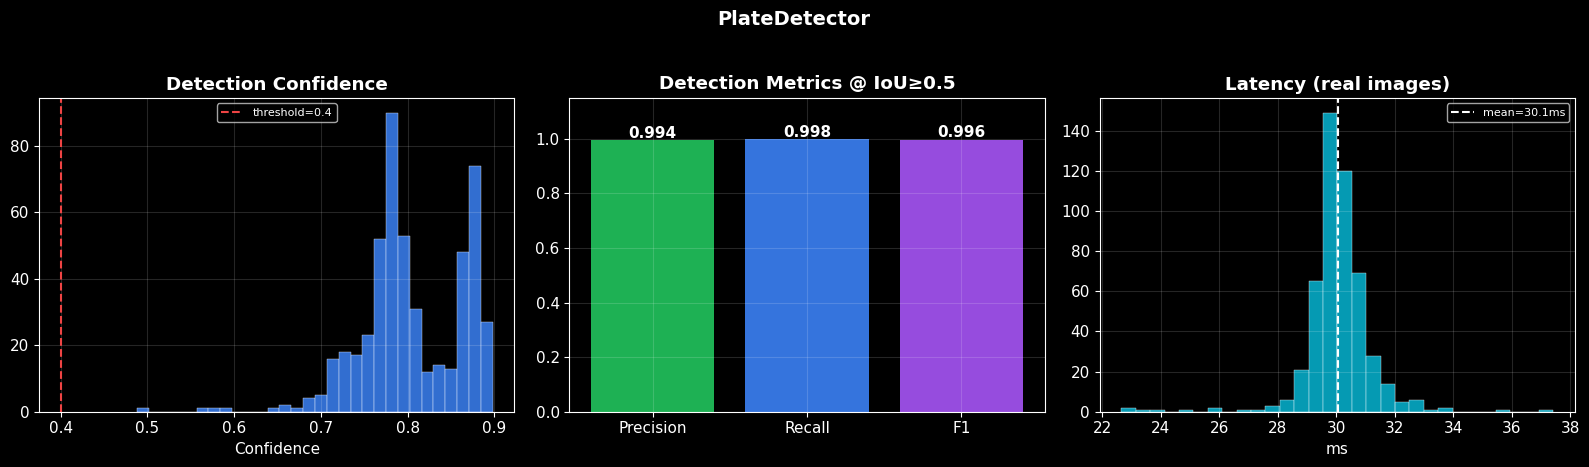

In [6]:
if det_acc and (det_acc['tp']+det_acc['fp']) > 0:
    tp,fp,fn = det_acc['tp'], det_acc['fp'], det_acc['fn']
    prec=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    f1=2*prec*rec/max(prec+rec,1e-6)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    axes[0].hist(det_acc['confs'], bins=30, color=C['blue'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[0].axvline(0.4, color=C['red'], linestyle='--', label='threshold=0.4')
    axes[0].set_title('Detection Confidence', fontweight='bold')
    axes[0].set_xlabel('Confidence'); axes[0].legend(fontsize=8)

    bars = axes[1].bar(['Precision','Recall','F1'], [prec,rec,f1],
                        color=[C['green'],C['blue'],C['purple']], alpha=0.9)
    for b,v in zip(bars,[prec,rec,f1]):
        axes[1].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                     ha='center', fontsize=11, fontweight='bold')
    axes[1].set_ylim(0,1.15); axes[1].set_title('Detection Metrics @ IoU≥0.5', fontweight='bold')

    axes[2].hist(det_acc['times_ms'], bins=30, color=C['cyan'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[2].axvline(np.mean(det_acc['times_ms']), color='white', linestyle='--',
                    label=f'mean={np.mean(det_acc["times_ms"]):.1f}ms')
    axes[2].set_title('Latency (real images)', fontweight='bold')
    axes[2].set_xlabel('ms'); axes[2].legend(fontsize=8)

    plt.suptitle('PlateDetector', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('/tmp/bench_det.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Không có detection accuracy data để vẽ')

---
## 2. PlateOCRYolo
> Updated 2026-04-06: benchmark OCR dùng trực tiếp text GT từ `paddle_format/0rec_gt.txt`; metric chính là `char-level`, kèm `string-level` và `pipeline-level`.
**Data**: ảnh crop biển số từ `yolo_plate_ocr_data/images/val` + YOLO char labels trong `yolo_plate_ocr_data/labels/val` + text GT trong `paddle_format/0rec_gt.txt`  
**Đo**: latency, char-level precision/recall/F1 (primary), plate-string accuracy, và metric sau `PlateValidator`


In [7]:
from engine import PlateOCRYolo
from main import PlateValidator

print('Loading PlateOCRYolo...')
plate_ocr = PlateOCRYolo(OCR_MODEL, imgsz=OCR_IMGSZ, conf=OCR_CONF, device=OCR_DEVICE)
validator = PlateValidator()
print('Done.\n')

# ── Latency (synthetic crops) ──
# Noise crop → 0 chars detected → NMS + sort/decode bị skip.
# Chỉ đo pure inference, KHÔNG đại diện cho latency thật.
ocr_latency = []
print('=== OCR YOLO Latency (inference-only, synthetic) ===')
for name, (w,h) in [('80x24',(80,24)),('160x48',(160,48)),('320x96',(320,96)),('480x140',(480,140))]:
    crop = np.random.randint(0,255,(h,w,3), dtype=np.uint8)
    s = bench(lambda c=crop: plate_ocr(c), n=N_BENCH, label=f'OCR {name} (inference-only)')
    ocr_latency.append(s)

# ── Latency (real crops) — metric chính ──
# Ảnh thật có ký tự → đo đầy đủ: inference + NMS + sort + decode.
if HAS_OCR:
    real_paths = sorted(
        glob.glob(os.path.join(OCR_IMAGES_DIR, '*.jpg')) +
        glob.glob(os.path.join(OCR_IMAGES_DIR, '*.jpeg')) +
        glob.glob(os.path.join(OCR_IMAGES_DIR, '*.png'))
    )[:50]
    loaded = [cv2.imread(p) for p in real_paths]
    loaded = [img for img in loaded if img is not None]
    if loaded:
        h0, w0 = loaded[0].shape[:2]
        print(f'\n=== OCR YOLO Latency (real crops) ===')
        print(f'  Real OCR crops: {len(loaded)} loaded, sample={w0}x{h0}')
        idx = [0]
        def ocr_real():
            crop = loaded[idx[0] % len(loaded)]
            idx[0] += 1
            return plate_ocr(crop)
        s = bench(ocr_real, n=min(N_BENCH, len(loaded)*3), label=f'OCR real {w0}x{h0}')
        ocr_latency.append(s)


Loading PlateOCRYolo...
Loading /home/somethink/parking_system/models/plate_ocr_yolov8n.engine for TensorRT inference...
[04/20/2026-00:36:03] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[04/20/2026-00:36:03] [TRT] [I] Loaded engine size: 7 MiB
[04/20/2026-00:36:03] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[04/20/2026-00:36:04] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +2, now: CPU 1, GPU 28 (MiB)
Done.

=== OCR YOLO Latency (inference-only, synthetic) ===
  OCR 80x24 (inference-only)      avg=  13.21ms  p95=  16.02ms  fps=  75.7
  OCR 160x48 (inference-only)     avg=  13.36ms  p95=  15.32ms  fps=  74.8
  OCR 320x96 (inference-only)     avg=   9.

In [8]:
import csv
from pathlib import Path

OCR_CHAR_IOU = 0.5
OCR_TEXT_SAMPLE_LIMIT = 500


def class_id_to_char(class_id: int) -> str:
    if 0 <= class_id <= 9:
        return str(class_id)
    if 10 <= class_id <= 35:
        return chr(ord('A') + class_id - 10)
    raise ValueError(f'class_id ngoài phạm vi hỗ trợ: {class_id}')


def parse_yolo_label_file(label_path: Path):
    objects = []
    with open(label_path, 'r', encoding='utf-8') as f:
        for line_num, raw_line in enumerate(f, start=1):
            line = raw_line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 5:
                print(f'[WARN] {label_path} dòng {line_num}: không đủ 5 phần tử -> bỏ qua')
                continue

            try:
                class_id = int(parts[0])
                cx = float(parts[1])
                cy = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])
                ch = class_id_to_char(class_id)
            except Exception as e:
                print(f'[WARN] {label_path} dòng {line_num}: parse lỗi -> {e}')
                continue

            objects.append({
                'char': ch,
                'cls_id': class_id,
                'cx': cx,
                'cy': cy,
                'w': w,
                'h': h,
            })
    return objects


def yolo_obj_to_xyxy(obj: dict, img_w: int, img_h: int):
    return (
        float((obj['cx'] - obj['w'] / 2) * img_w),
        float((obj['cy'] - obj['h'] / 2) * img_h),
        float((obj['cx'] + obj['w'] / 2) * img_w),
        float((obj['cy'] + obj['h'] / 2) * img_h),
    )


def prepare_ocr_crop(plate_crop: np.ndarray) -> np.ndarray:
    if plate_crop is None or plate_crop.size == 0:
        return plate_crop
    h = plate_crop.shape[0]
    if h < 48:
        scale = 48.0 / h
        plate_crop = cv2.resize(
            plate_crop, None, fx=scale, fy=scale,
            interpolation=cv2.INTER_CUBIC)
    return plate_crop


def run_ocr_model(plate_crop: np.ndarray):
    crop = prepare_ocr_crop(plate_crop)
    if crop is None or crop.size == 0:
        return crop, []

    results = plate_ocr.model(
        crop, imgsz=plate_ocr.imgsz,
        conf=plate_ocr.conf, verbose=False)

    chars = []
    for r in results:
        boxes = getattr(r, 'boxes', None)
        if boxes is None:
            continue
        xyxy = boxes.xyxy.cpu().numpy() if hasattr(boxes.xyxy, 'cpu') else boxes.xyxy.numpy()
        confs = boxes.conf.cpu().numpy() if hasattr(boxes.conf, 'cpu') else boxes.conf.numpy()
        clss = boxes.cls.cpu().numpy().astype(int) if hasattr(boxes.cls, 'cpu') else boxes.cls.numpy().astype(int)
        for box, cf, cls_id in zip(xyxy, confs, clss):
            x1, y1, x2, y2 = map(float, box)
            chars.append({
                'char': class_id_to_char(int(cls_id)),
                'cls_id': int(cls_id),
                'conf': float(cf),
                'cx': float((x1 + x2) / 2 / crop.shape[1]),
                'cy': float((y1 + y2) / 2 / crop.shape[0]),
                'w': float((x2 - x1) / crop.shape[1]),
                'h': float((y2 - y1) / crop.shape[0]),
                'xyxy': (x1, y1, x2, y2),
            })
    return crop, chars


def sort_chars_by_rows(objects: list, img_h: int = 0, row_gap_ratio: float = 0.18):
    """
    Sort ký tự theo vị trí — cùng ý tưởng robust với engine.py _sort_chars.

    Thay vì dùng y_range thô, hàm này fit một đường y(x) để loại bỏ tilt,
    rồi chỉ tách 2 dòng khi residual theo y đủ lớn và hai cụm còn overlap
    theo trục x.
    """
    ordered = sorted(objects, key=lambda o: o['cx'])
    if len(ordered) < 4:
        return ordered

    xs = np.array([o['cx'] for o in ordered], dtype=np.float32)
    ys = np.array([o['cy'] for o in ordered], dtype=np.float32)
    x_mean = float(xs.mean())
    y_mean = float(ys.mean())
    x_var = float(np.sum((xs - x_mean) ** 2))
    if x_var <= 1e-6:
        return ordered

    slope = float(np.sum((xs - x_mean) * (ys - y_mean)) / x_var)
    residuals = ys - (y_mean + slope * (xs - x_mean))
    residual_range = float(residuals.max() - residuals.min())
    heights = sorted(o.get('h', 0.0) for o in ordered if o.get('h', 0.0) > 0)
    median_h = heights[len(heights) // 2] if heights else 0.2
    split_threshold = max(row_gap_ratio, median_h * 0.6)
    if residual_range <= split_threshold:
        return ordered

    residual_mid = float((residuals.min() + residuals.max()) / 2)
    upper = [o for o, r in zip(ordered, residuals) if r < residual_mid]
    lower = [o for o, r in zip(ordered, residuals) if r >= residual_mid]
    if len(upper) < 2 or len(lower) < 2:
        return ordered

    upper_x_min = min(o['cx'] for o in upper)
    upper_x_max = max(o['cx'] for o in upper)
    lower_x_min = min(o['cx'] for o in lower)
    lower_x_max = max(o['cx'] for o in lower)
    if upper_x_max < lower_x_min or lower_x_max < upper_x_min:
        return ordered

    upper = sorted(upper, key=lambda o: o['cx'])
    lower = sorted(lower, key=lambda o: o['cx'])
    upper_y = sum(o['cy'] for o in upper) / len(upper)
    lower_y = sum(o['cy'] for o in lower) / len(lower)
    if upper_y > lower_y:
        upper, lower = lower, upper
    return upper + lower


def decode_pred_chars(pred_chars: list, crop_h: int):
    ordered = sort_chars_by_rows(pred_chars, img_h=crop_h)
    raw = ''.join(obj['char'] for obj in ordered)
    conf = float(np.mean([obj.get('conf', 0.0) for obj in ordered])) if ordered else 0.0
    return raw, conf


def normalize_ocr_text(text: str) -> str:
    if text is None:
        return ''
    text = str(text).strip().upper()
    for ch in [' ', '-', '.', '_']:
        text = text.replace(ch, '')
    return text


def edit_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)

    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        curr = [i]
        for j, cb in enumerate(b, start=1):
            cost = 0 if ca == cb else 1
            curr.append(min(
                prev[j] + 1,
                curr[j - 1] + 1,
                prev[j - 1] + cost,
            ))
        prev = curr
    return prev[-1]


def load_ocr_text_gt_map(path: str):
    gt_map = {}
    p = Path(path)
    if not p.exists():
        return gt_map

    with open(p, 'r', encoding='utf-8') as f:
        for line_num, raw_line in enumerate(f, start=1):
            line = raw_line.strip()
            if not line:
                continue

            if '	' in line:
                image_name, text = line.split('	', 1)
            elif ',' in line and line_num == 1 and 'image' in line.lower() and 'text' in line.lower():
                continue
            elif ',' in line:
                image_name, text = line.split(',', 1)
            else:
                print(f'[WARN] OCR text GT dòng {line_num} không đúng format -> bỏ qua: {line[:80]}')
                continue

            image_name = image_name.strip()
            text = normalize_ocr_text(text)
            if not image_name:
                continue
            gt_map[Path(image_name).name] = text
            gt_map[Path(image_name).stem] = text
    return gt_map


def load_ocr_samples(images_dir: str, labels_dir: str):
    img_dir = Path(images_dir)
    lbl_dir = Path(labels_dir)
    samples = []

    for img_path in sorted(img_dir.iterdir()):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}:
            continue
        label_path = lbl_dir / f'{img_path.stem}.txt'
        if not label_path.exists():
            continue
        gt_chars = parse_yolo_label_file(label_path)
        samples.append({
            'img_path': str(img_path),
            'label_path': str(label_path),
            'gt_chars': gt_chars,
        })
    return samples


def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    if union <= 0:
        return 0.0
    return inter / union


def match_char_boxes(pred_chars: list, gt_chars: list, crop_shape, iou_thr: float = OCR_CHAR_IOU):
    img_h, img_w = crop_shape[:2]
    preds = []
    for pred in pred_chars:
        box = pred.get('xyxy')
        if box is None:
            box = yolo_obj_to_xyxy(pred, img_w, img_h)
        preds.append({**pred, 'xyxy': box})

    gts = [{**gt, 'xyxy': yolo_obj_to_xyxy(gt, img_w, img_h)} for gt in gt_chars]

    pairs = []
    for pi, pred in enumerate(preds):
        for gi, gt in enumerate(gts):
            iou = box_iou_xyxy(pred['xyxy'], gt['xyxy'])
            if iou >= iou_thr:
                pairs.append((iou, pi, gi))
    pairs.sort(reverse=True)

    matched_pred = set()
    matched_gt = set()
    tp = 0
    cls_err = 0
    confusions = Counter()

    for iou, pi, gi in pairs:
        if pi in matched_pred or gi in matched_gt:
            continue
        matched_pred.add(pi)
        matched_gt.add(gi)
        if preds[pi]['char'] == gts[gi]['char']:
            tp += 1
        else:
            cls_err += 1
            confusions[(gts[gi]['char'], preds[pi]['char'])] += 1

    fp = len(preds) - len(matched_pred)
    fn = len(gts) - len(matched_gt)
    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'cls_err': cls_err,
        'n_pred': len(preds),
        'n_gt': len(gts),
        'confusions': confusions,
    }


print('OCR benchmark helpers loaded')
print(f'  OCR text GT: {OCR_TEXT_GT} -> {"FOUND" if os.path.exists(OCR_TEXT_GT) else "MISSING"}')


OCR benchmark helpers loaded
  OCR text GT: paddle_format/0rec_gt.txt -> FOUND


In [9]:
# ── Xóa samples có GT dạng \d{2}[A-Z]\d{4} (PlateValidator không hỗ trợ format 4-số) ──
# Tác động: xóa file khỏi OCR val + Det val + rewrite OCR_TEXT_GT
import re as _re

PLATE_PATTERN_TO_REMOVE = _re.compile(r'^\d{2}[A-Z]\d{4}$')

# Quét GT file, lấy image name có GT khớp pattern
to_remove_names = {}  # image_name -> gt_text
with open(OCR_TEXT_GT, 'r', encoding='utf-8') as f:
    for line in f:
        raw = line.rstrip('\n')
        if not raw.strip():
            continue
        if '\t' in raw:
            img_name, text = raw.split('\t', 1)
        elif ',' in raw:
            img_name, text = raw.split(',', 1)
        else:
            continue
        img_name = Path(img_name.strip()).name
        text_norm = normalize_ocr_text(text)
        if PLATE_PATTERN_TO_REMOVE.match(text_norm):
            to_remove_names[img_name] = text_norm

print(f'Tìm thấy {len(to_remove_names)} samples có GT khớp pattern {PLATE_PATTERN_TO_REMOVE.pattern}')
for name, gt in list(sorted(to_remove_names.items()))[:10]:
    print(f'  {name:35s} → {gt}')
if len(to_remove_names) > 10:
    print(f'  ... và {len(to_remove_names) - 10} trường hợp khác')

# Xóa file khỏi disk (OCR val + Det val)
dirs = [
    ('ocr_img', Path(OCR_IMAGES_DIR), None),
    ('ocr_lbl', Path(OCR_LABELS_DIR), '.txt'),
    ('det_img', Path(DET_IMAGES_DIR), None),
    ('det_lbl', Path(DET_LABELS_DIR), '.txt'),
]
deleted = {k: 0 for k, _, _ in dirs}
for name in to_remove_names:
    stem = Path(name).stem
    for key, d, ext in dirs:
        target = d / (f'{stem}{ext}' if ext else name)
        if target.exists():
            target.unlink()
            deleted[key] += 1

print(f'\nĐã xóa file:')
for k, v in deleted.items():
    print(f'  {k:10s}: {v}')

# Rewrite OCR_TEXT_GT bỏ các entry đã xóa
if to_remove_names:
    removed = set(to_remove_names.keys())
    kept = []
    with open(OCR_TEXT_GT, 'r', encoding='utf-8') as f:
        for line in f:
            raw = line.rstrip('\n')
            if not raw.strip():
                kept.append(raw)
                continue
            if '\t' in raw:
                img_name = raw.split('\t', 1)[0]
            elif ',' in raw:
                img_name = raw.split(',', 1)[0]
            else:
                kept.append(raw)
                continue
            if Path(img_name.strip()).name in removed:
                continue
            kept.append(raw)
    with open(OCR_TEXT_GT, 'w', encoding='utf-8') as f:
        f.write('\n'.join(kept).rstrip() + '\n')
    print(f'Đã rewrite {OCR_TEXT_GT}: còn {len([l for l in kept if l.strip()])} dòng')


Tìm thấy 0 samples có GT khớp pattern ^\d{2}[A-Z]\d{4}$

Đã xóa file:
  ocr_img   : 0
  ocr_lbl   : 0
  det_img   : 0
  det_lbl   : 0


In [10]:
# ── OCR Accuracy ──
ocr_bench = None

if not HAS_OCR:
    print('⚠️  SKIP — chưa set OCR_IMAGES_DIR và/hoặc OCR_LABELS_DIR')
    print('   Sửa ở cell [config] rồi chạy lại.')
else:
    samples = load_ocr_samples(OCR_IMAGES_DIR, OCR_LABELS_DIR)
    text_gt_map = load_ocr_text_gt_map(OCR_TEXT_GT)
    if not text_gt_map:
        raise FileNotFoundError(f'Không đọc được OCR text GT: {OCR_TEXT_GT}')

    text_gt_hits = sum(
        1 for s in samples
        if Path(s['img_path']).name in text_gt_map
        or Path(s['img_path']).stem in text_gt_map)

    print(f'Found {len(samples)} OCR image-label pairs from YOLO val split')
    print(f'Loaded OCR text GT: {len(text_gt_map)} keys, overlap={text_gt_hits} samples')
    if text_gt_hits == 0:
        raise ValueError('OCR text GT không match image nào trong OCR val split')

    ocr_bench = {
        'times_ms': [],
        'char': {
            'n_samples': 0,
            'tp': 0,
            'fp': 0,
            'fn': 0,
            'cls_err': 0,
            'plate_exact': 0,
            'confusions': Counter(),
        },
        'string': {
            'n': 0,
            'exact_raw': 0,
            'exact_valid': 0,
            'validator_pass_pred': 0,
            'validator_pass_gt': 0,
            'edit_dists': [],
            'cers': [],
            'confs': [],
            'details': [],
        },
    }

    for sample in samples:
        crop0 = cv2.imread(sample['img_path'])
        if crop0 is None or crop0.size == 0:
            continue

        t0 = time.perf_counter()
        crop, pred_chars = run_ocr_model(crop0)
        infer_ms = (time.perf_counter() - t0) * 1000
        ocr_bench['times_ms'].append(infer_ms)

        if crop is None or crop.size == 0:
            continue

        # String-level: gọi plate_ocr() trực tiếp để đo đúng runtime path.
        # decode_pred_chars vẫn giữ lại cho debug/helper, nhưng metric string
        # nên bám đúng engine.py __call__() để tránh lệch pipeline thật.
        raw, conf = plate_ocr(crop0)
        char_stats = match_char_boxes(pred_chars, sample['gt_chars'], crop.shape)

        ocr_bench['char']['n_samples'] += 1
        for key in ['tp', 'fp', 'fn', 'cls_err']:
            ocr_bench['char'][key] += char_stats[key]
        ocr_bench['char']['confusions'].update(char_stats['confusions'])
        if char_stats['tp'] == char_stats['n_gt'] and char_stats['fp'] == 0 and char_stats['fn'] == 0:
            ocr_bench['char']['plate_exact'] += 1

        gt_text = (
            text_gt_map.get(Path(sample['img_path']).name)
            or text_gt_map.get(Path(sample['img_path']).stem)
        )
        if gt_text is None:
            continue

        pred_eval = normalize_ocr_text(raw)
        gt_eval = normalize_ocr_text(gt_text)
        pred_valid = validator(raw)
        gt_valid = validator(gt_text)
        ed = edit_distance(pred_eval, gt_eval)
        cer = ed / max(len(gt_eval), 1)

        s = ocr_bench['string']
        s['n'] += 1
        s['exact_raw'] += int(pred_eval == gt_eval)
        s['exact_valid'] += int(bool(pred_valid) and bool(gt_valid) and pred_valid == gt_valid)
        s['validator_pass_pred'] += int(bool(pred_valid))
        s['validator_pass_gt'] += int(bool(gt_valid))
        s['edit_dists'].append(ed)
        s['cers'].append(cer)
        s['confs'].append(conf)
        s['details'].append({
            'img': Path(sample['img_path']).name,
            'gt': gt_eval,
            'pred_raw': pred_eval,
            'pred_valid': pred_valid or '',
            'gt_valid': gt_valid or '',
            'edit_dist': ed,
            'cer': cer,
            'conf': conf,
            'tp': char_stats['tp'],
            'fp': char_stats['fp'],
            'fn': char_stats['fn'],
            'cls_err': char_stats['cls_err'],
        })

    c = ocr_bench['char']
    tp, fp, fn = c['tp'], c['fp'], c['fn']
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-6)

    print('\n=== OCR YOLO Character-Level (primary) ===')
    print(f"Samples              : {c['n_samples']}")
    print(f"TP / FP / FN         : {tp} / {fp} / {fn}")
    print(f"Cls errors           : {c['cls_err']}")
    print(f"Precision / Recall   : {prec:.3f} / {rec:.3f}")
    print(f"F1                   : {f1:.3f}")
    print(f"Crop exact match     : {c['plate_exact'] / max(c['n_samples'], 1):.3f}")

    s = ocr_bench['string']
    print('\n=== OCR YOLO Plate String (from paddle_format/0rec_gt.txt) ===')
    print(f"Samples w/ text GT   : {s['n']}")
    print(f"Raw exact match      : {s['exact_raw'] / max(s['n'], 1):.3f}")
    print(f"After validator      : {s['exact_valid'] / max(s['n'], 1):.3f}")
    print(f"Validator pass (OCR) : {s['validator_pass_pred'] / max(s['n'], 1):.3f}")
    print(f"Validator pass (GT)  : {s['validator_pass_gt'] / max(s['n'], 1):.3f}")
    print(f"Mean edit distance   : {np.mean(s['edit_dists']) if s['edit_dists'] else 0.0:.3f}")
    print(f"Mean CER             : {np.mean(s['cers']) if s['cers'] else 0.0:.3f}")
    print(f"Mean conf            : {np.mean(s['confs']) if s['confs'] else 0.0:.3f}")

    print('\n=== OCR YOLO Latency ===')
    print(f"Mean infer           : {np.mean(ocr_bench['times_ms']):.2f} ms")
    print(f"P95 infer            : {np.percentile(ocr_bench['times_ms'], 95):.2f} ms")
    print(f"FPS                  : {1000 / max(np.mean(ocr_bench['times_ms']), 1e-6):.1f}")

    worst = sorted(ocr_bench['string']['details'], key=lambda d: (d['cer'], d['edit_dist']), reverse=True)
    if worst:
        print('\nWorst string cases:')
        for row in worst:
            print(
                f"- {row['img']}: gt={row['gt']} pred={row['pred_raw']} "
                f"valid={row['pred_valid'] or '-'} cer={row['cer']:.3f} conf={row['conf']:.2f} "
                f"[tp={row['tp']} fp={row['fp']} fn={row['fn']} cls={row['cls_err']}]"
            )

    top_confusions = ocr_bench['char']['confusions'].most_common(100)
    if top_confusions:
        print('\nTop character confusions:')
        for (gt_ch, pred_ch), cnt in top_confusions:
            print(f'- {gt_ch} -> {pred_ch}: {cnt}')


Found 450 OCR image-label pairs from YOLO val split
Loaded OCR text GT: 6328 keys, overlap=450 samples

=== OCR YOLO Character-Level (primary) ===
Samples              : 450
TP / FP / FN         : 3832 / 31 / 4
Cls errors           : 27
Precision / Recall   : 0.992 / 0.999
F1                   : 0.995
Crop exact match     : 0.893

=== OCR YOLO Plate String (from paddle_format/0rec_gt.txt) ===
Samples w/ text GT   : 450
Raw exact match      : 0.904
After validator      : 0.904
Validator pass (OCR) : 0.987
Validator pass (GT)  : 0.984
Mean edit distance   : 0.118
Mean CER             : 0.015
Mean conf            : 0.878

=== OCR YOLO Latency ===
Mean infer           : 12.18 ms
P95 infer            : 12.77 ms
FPS                  : 82.1

Worst string cases:
- 4CarLongPlate781.jpg: gt=G01177 pred=M6D1177 valid=- cer=0.500 conf=0.81 [tp=6 fp=1 fn=0 cls=0]
- 5xemay1347.jpg: gt=99L123882 pred=51I23882 valid=- cer=0.444 conf=0.84 [tp=7 fp=0 fn=1 cls=1]
- 5CarLongPlate757.jpg: gt=1G69160 pred=5

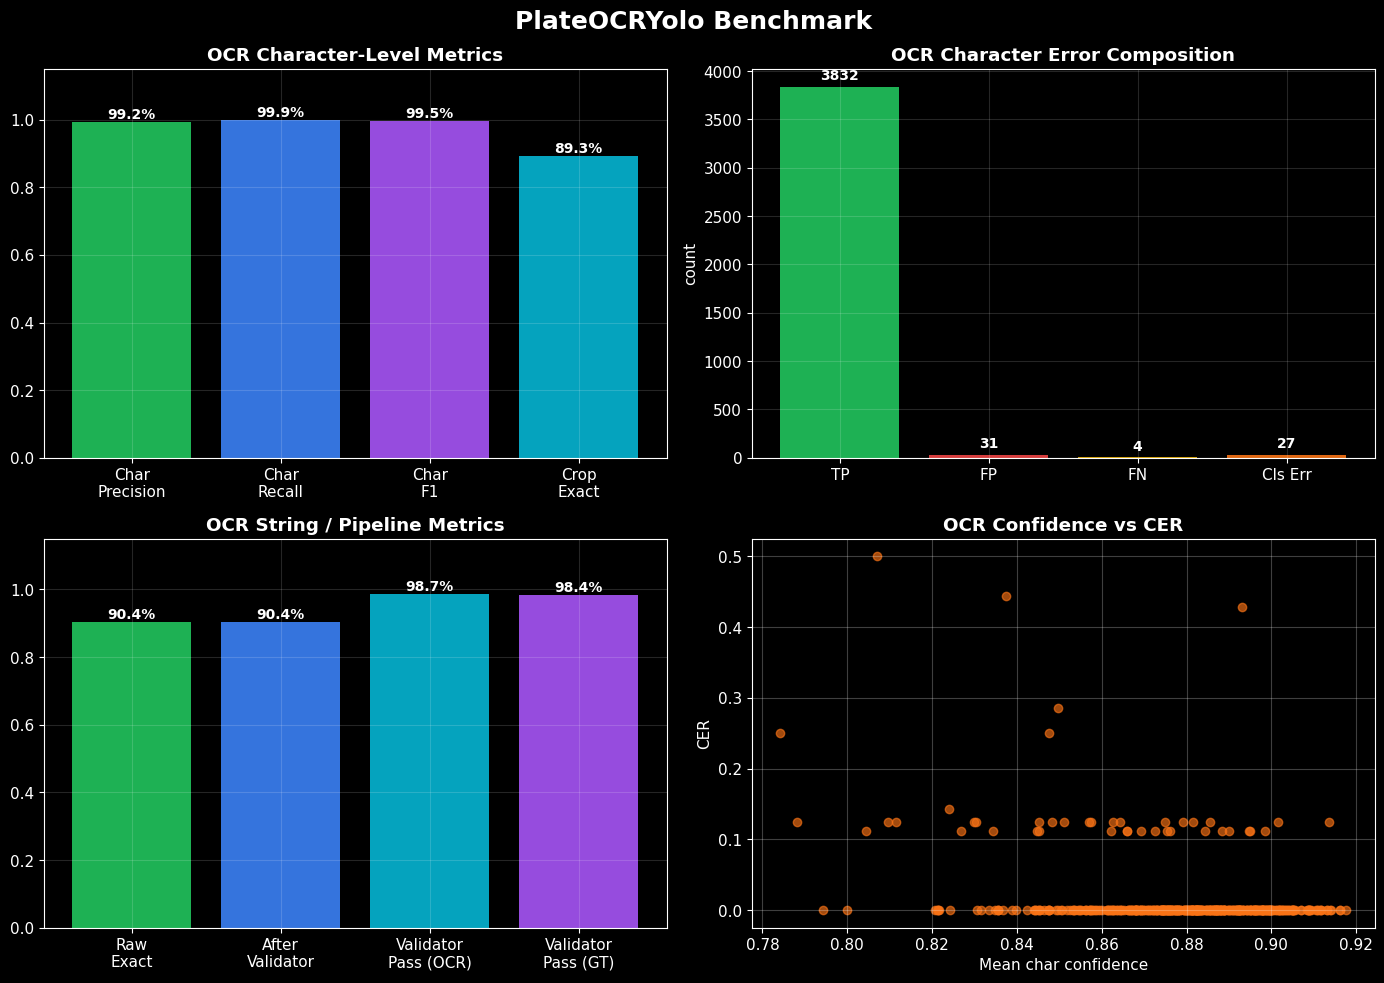

In [11]:
if ocr_bench and ocr_bench['char']['n_samples']:
    c = ocr_bench['char']
    tp, fp, fn = c['tp'], c['fp'], c['fn']
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-6)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    char_metrics = ['Char\nPrecision', 'Char\nRecall', 'Char\nF1', 'Crop\nExact']
    char_vals = [prec, rec, f1, c['plate_exact'] / max(c['n_samples'], 1)]
    bars = axes[0,0].bar(char_metrics, char_vals,
                         color=[C['green'], C['blue'], C['purple'], C['cyan']], alpha=0.9)
    for b, v in zip(bars, char_vals):
        axes[0,0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v*100:.1f}%',
                       ha='center', fontsize=10, fontweight='bold')
    axes[0,0].set_ylim(0,1.15)
    axes[0,0].set_title('OCR Character-Level Metrics', fontweight='bold')

    err_labels = ['TP', 'FP', 'FN', 'Cls Err']
    err_vals = [c['tp'], c['fp'], c['fn'], c['cls_err']]
    bars = axes[0,1].bar(err_labels, err_vals,
                         color=[C['green'], C['red'], C['yellow'], C['orange']], alpha=0.9)
    for b, v in zip(bars, err_vals):
        axes[0,1].text(b.get_x() + b.get_width() / 2, v + max(max(err_vals) * 0.02, 1), f'{v}',
                       ha='center', fontsize=10, fontweight='bold')
    axes[0,1].set_title('OCR Character Error Composition', fontweight='bold')
    axes[0,1].set_ylabel('count')

    s = ocr_bench['string']
    string_metrics = ['Raw\nExact', 'After\nValidator', 'Validator\nPass (OCR)', 'Validator\nPass (GT)']
    string_vals = [
        s['exact_raw'] / max(s['n'], 1),
        s['exact_valid'] / max(s['n'], 1),
        s['validator_pass_pred'] / max(s['n'], 1),
        s['validator_pass_gt'] / max(s['n'], 1),
    ]
    bars = axes[1,0].bar(string_metrics, string_vals,
                         color=[C['green'], C['blue'], C['cyan'], C['purple']], alpha=0.9)
    for b, v in zip(bars, string_vals):
        axes[1,0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v*100:.1f}%',
                       ha='center', fontsize=10, fontweight='bold')
    axes[1,0].set_ylim(0, 1.15)
    axes[1,0].set_title('OCR String / Pipeline Metrics', fontweight='bold')

    cer_vals = s['cers'] if s['cers'] else [0.0]
    conf_vals = s['confs'] if s['confs'] else [0.0]
    axes[1,1].scatter(conf_vals, cer_vals, alpha=0.65, color=C['orange'])
    axes[1,1].set_xlabel('Mean char confidence')
    axes[1,1].set_ylabel('CER')
    axes[1,1].set_title('OCR Confidence vs CER', fontweight='bold')
    axes[1,1].grid(alpha=0.25)

    plt.suptitle('PlateOCRYolo Benchmark', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()


---
## 3. FaceEngine — LFW Dataset
**Data**: LFW (Labeled Faces in the Wild) — ~13,000 ảnh mặt  
**Đo**: detection rate, same/diff person similarity, optimal threshold, latency

In [12]:
import os, glob, tarfile, urllib.request
from pathlib import Path
from collections import defaultdict

# ===== Paths =====
LFW_TGZ = str(PROJECT_DIR / 'benchmark_data' / 'lfw-funneled.tgz')
LFW_EXTRACT = str(PROJECT_DIR / 'benchmark_data')
LFW_ROOT = os.path.join(LFW_EXTRACT, 'lfw_funneled')

os.makedirs(LFW_EXTRACT, exist_ok=True)

# ===== Download URLs =====
LFW_URLS = [
    'https://ndownloader.figshare.com/files/5976015',   # mirror used by scikit-learn
    'http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz', # original source
]

def download_with_fallback(urls, dst):
    last_err = None
    for url in urls:
        try:
            print(f'Trying: {url}')
            urllib.request.urlretrieve(url, dst)
            print('Download OK')
            return url
        except Exception as e:
            print(f'Failed: {e}')
            last_err = e
            # xóa file lỗi / tải dở
            if os.path.exists(dst):
                try:
                    os.remove(dst)
                except:
                    pass
    raise RuntimeError(f'Cannot download LFW from any source. Last error: {last_err}')

# ===== Main =====
if os.path.isdir(LFW_ROOT) and len(os.listdir(LFW_ROOT)) > 100:
    print(f'✅ LFW exists: {LFW_ROOT}')
else:
    print('Downloading LFW...')
    if not os.path.exists(LFW_TGZ):
        used_url = download_with_fallback(LFW_URLS, LFW_TGZ)
        print(f'Used URL: {used_url}')
    else:
        print(f'Found existing archive: {LFW_TGZ}')

    print('Extracting...')
    with tarfile.open(LFW_TGZ, 'r:gz') as tar:
        tar.extractall(LFW_EXTRACT)
    print('Done.')

lfw_images = sorted(glob.glob(os.path.join(LFW_ROOT, '*', '*.jpg')))
print(f'LFW images: {len(lfw_images)}')

# Người có >= 2 ảnh
person_imgs = defaultdict(list)
for p in lfw_images:
    person_imgs[Path(p).parent.name].append(p)

multi = {k: v for k, v in person_imgs.items() if len(v) >= 2}
print(f'Persons with >= 2 images: {len(multi)}')

✅ LFW exists: /home/somethink/parking_system/benchmark_data/lfw_funneled
LFW images: 11624
Persons with >= 2 images: 1391


In [13]:
from engine import FaceEngine

print('Loading FaceEngine...')
face_eng = FaceEngine(model_pack='buffalo_sc', det_size=(640, 640))
print('Done.\n')

face_latency = []
print('=== FaceEngine Latency ===')
for name, (w,h) in [('640x480',(640,480)), ('1280x720',(1280,720))]:
    img = np.random.randint(0,255,(h,w,3), dtype=np.uint8)
    s = bench(lambda img=img: face_eng(img), n=N_BENCH, label=f'Face {name}')
    face_latency.append(s)

Loading FaceEngine...


/home/somethink/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}, 'TensorrtExecutionProvider': {'trt_load_user_initializer': '0', 'trt_op_types_to_exclude': '', 'trt_external_data_bytestream': '0', 'trt_preview_feature

In [14]:
# ── Detection rate trên LFW ──
N_SAMPLE = 200
sample = random.sample(lfw_images, min(N_SAMPLE, len(lfw_images)))

face_acc = {'detected':0, 'no_face':0, 'multi':0, 'confs':[], 'times_ms':[]}

for p in sample:
    img = cv2.imread(p)
    if img is None: continue
    t0 = time.perf_counter()
    faces = face_eng(img)
    face_acc['times_ms'].append((time.perf_counter()-t0)*1000)
    if len(faces)==0: face_acc['no_face']+=1
    elif len(faces)==1:
        face_acc['detected']+=1; face_acc['confs'].append(faces[0]['conf'])
    else:
        face_acc['multi']+=1; face_acc['confs'].append(max(f['conf'] for f in faces))

tot = face_acc['detected']+face_acc['no_face']+face_acc['multi']
print(f'=== Face Detection ({tot} images) ===')
print(f'  Detected: {face_acc["detected"]} ({100*face_acc["detected"]/max(tot,1):.1f}%)')
print(f'  No face:  {face_acc["no_face"]} ({100*face_acc["no_face"]/max(tot,1):.1f}%)')
print(f'  Multi:    {face_acc["multi"]}')

=== Face Detection (200 images) ===
  Detected: 187 (93.5%)
  No face:  0 (0.0%)
  Multi:    13


In [15]:
# ── Same vs Different person similarity ──
N_PAIRS = 100

def get_emb(path):
    img = cv2.imread(path)
    if img is None: return None
    faces = face_eng(img)
    return max(faces, key=lambda f: f['conf'])['embedding'] if faces else None

# Same person
same_sims = []
for name, imgs in list(multi.items()):
    if len(same_sims) >= N_PAIRS: break
    e1, e2 = get_emb(imgs[0]), get_emb(imgs[1])
    if e1 is not None and e2 is not None:
        same_sims.append(float(np.dot(e1, e2)))

# Different person
diff_sims = []
all_p = list(person_imgs.keys())
for _ in range(N_PAIRS * 5):
    if len(diff_sims) >= N_PAIRS: break
    p1, p2 = random.sample(all_p, 2)
    e1, e2 = get_emb(person_imgs[p1][0]), get_emb(person_imgs[p2][0])
    if e1 is not None and e2 is not None:
        diff_sims.append(float(np.dot(e1, e2)))

print(f'Same person  (n={len(same_sims)}):  mean={np.mean(same_sims):.3f}')
print(f'Diff person  (n={len(diff_sims)}):  mean={np.mean(diff_sims):.3f}')

# Best threshold
best_thr, best_acc = 0, 0
for thr in np.arange(0.0, 1.0, 0.01):
    tp = sum(1 for s in same_sims if s >= thr)
    tn = sum(1 for s in diff_sims if s < thr)
    acc = (tp+tn)/(len(same_sims)+len(diff_sims))
    if acc > best_acc: best_acc, best_thr = acc, thr

print(f'\nBest threshold: {best_thr:.2f} (acc={best_acc:.3f})')
print(f'Config threshold: 0.45  ({"OK ✅" if abs(best_thr-0.45)<0.15 else "KHÁC ⚠️"})')

Same person  (n=100):  mean=0.623
Diff person  (n=100):  mean=0.018

Best threshold: 0.23 (acc=1.000)
Config threshold: 0.45  (KHÁC ⚠️)


In [16]:
# ── Lọc LFW: xóa ảnh detect được != 1 mặt khỏi multi dict ──
# Chạy face_eng trên từng ảnh, giữ lại chỉ các ảnh có đúng 1 face.
# Sau đó rebuild multi để chỉ giữ identity còn >= 2 ảnh hợp lệ.

print('Filtering LFW images: giữ lại ảnh có đúng 1 face...')

filtered_imgs = {}      # path → 'ok' | 'no_face' | 'multi_face'
filtered_multi = {}     # identity → danh sách ảnh hợp lệ

n_ok = n_no_face = n_multi = 0
all_paths = [p for imgs in multi.values() for p in imgs]
total = len(all_paths)

for idx, path in enumerate(all_paths):
    if idx % 500 == 0:
        print(f'  {idx}/{total}...', end='\r')
    img = cv2.imread(path)
    if img is None:
        filtered_imgs[path] = 'no_face'
        n_no_face += 1
        continue
    faces = face_eng(img)
    if len(faces) == 0:
        filtered_imgs[path] = 'no_face'
        n_no_face += 1
    elif len(faces) > 1:
        filtered_imgs[path] = 'multi_face'
        n_multi += 1
    else:
        filtered_imgs[path] = 'ok'
        n_ok += 1

print(f'  {total}/{total}... done')

# Rebuild multi: chỉ giữ identity có >= 2 ảnh 'ok'
n_identity_before = len(multi)
for name, imgs in multi.items():
    valid = [p for p in imgs if filtered_imgs.get(p) == 'ok']
    if len(valid) >= 2:
        filtered_multi[name] = valid

n_identity_after = len(filtered_multi)
n_dropped_id = n_identity_before - n_identity_after

print(f'\n=== Kết quả lọc ảnh LFW ===')
print(f'  Tổng ảnh quét      : {total}')
print(f'  ok (1 face)        : {n_ok}   ({100*n_ok/max(total,1):.1f}%)')
print(f'  no_face            : {n_no_face}  ({100*n_no_face/max(total,1):.1f}%)')
print(f'  multi_face (>=2)   : {n_multi}  ({100*n_multi/max(total,1):.1f}%)')
print(f'  Identity trước lọc : {n_identity_before}')
print(f'  Identity sau lọc   : {n_identity_after}  (còn >= 2 ảnh hợp lệ)')
print(f'  Identity bị loại   : {n_dropped_id}')

# Xóa hẳn các ảnh bị loại khỏi disk
n_deleted = n_delete_err = 0
for path, status in filtered_imgs.items():
    if status != 'ok':
        try:
            os.remove(path)
            n_deleted += 1
        except Exception as e:
            print(f'  [WARN] Không xóa được {path}: {e}')
            n_delete_err += 1

print(f'  Đã xóa khỏi disk    : {n_deleted} file')
if n_delete_err:
    print(f'  Lỗi khi xóa         : {n_delete_err} file')

# Ghi đè multi để các cell sau dùng bộ dữ liệu sạch
multi = filtered_multi
print(f'\n→ multi đã được cập nhật: {len(multi)} identities với tổng '
      f'{sum(len(v) for v in multi.values())} ảnh hợp lệ')

Filtering LFW images: giữ lại ảnh có đúng 1 face...
  7313/7313... done

=== Kết quả lọc ảnh LFW ===
  Tổng ảnh quét      : 7313
  ok (1 face)        : 7313   (100.0%)
  no_face            : 0  (0.0%)
  multi_face (>=2)   : 0  (0.0%)
  Identity trước lọc : 1391
  Identity sau lọc   : 1391  (còn >= 2 ảnh hợp lệ)
  Identity bị loại   : 0
  Đã xóa khỏi disk    : 0 file

→ multi đã được cập nhật: 1391 identities với tổng 7313 ảnh hợp lệ


In [17]:
# ── Lọc outlier trong từng identity bằng cosine similarity ──
# Quy tắc STRICT: sau khi chạy, mọi cặp ảnh còn lại trong cùng folder đều có sim > thr.
# - Folder có đúng 2 ảnh: nếu sim <= thr → xóa cả folder.
# - Folder có >=3 ảnh: greedy vertex cover — lặp, xóa ảnh có nhiều cặp xấu nhất
#   (tie-break: mean sim với phần còn lại thấp nhất) cho đến khi không còn cặp
#   nào sim <= thr. Nếu còn < 2 ảnh → loại identity khỏi multi.
import shutil

OUTLIER_SIM_THR = 0.3

print(f'Computing embeddings để phát hiện outlier (sim_thr={OUTLIER_SIM_THR})...')
identity_embs = {}   # name → {path: embedding}
total_imgs = sum(len(v) for v in multi.values())
scanned = 0
for name, paths in multi.items():
    embs = {}
    for p in paths:
        scanned += 1
        if scanned % 500 == 0:
            print(f'  {scanned}/{total_imgs}...', end='\r')
        img = cv2.imread(p)
        if img is None:
            continue
        faces = face_eng(img)
        if len(faces) == 1:
            embs[p] = faces[0]['embedding']
    identity_embs[name] = embs
print(f'  {scanned}/{total_imgs}... done')

n_img_removed = 0
n_folder_removed = 0
to_drop_ids = set()
outlier_log = []     # (name, path, reason)

for name, embs_dict in identity_embs.items():
    paths = list(embs_dict.keys())
    n = len(paths)
    if n < 2:
        to_drop_ids.add(name)
        continue

    if n == 2:
        p1, p2 = paths
        sim = float(np.dot(embs_dict[p1], embs_dict[p2]))
        if sim <= OUTLIER_SIM_THR:
            # Xóa cả folder
            folder = Path(p1).parent
            try:
                shutil.rmtree(folder)
                n_folder_removed += 1
                n_img_removed += 2
                outlier_log.append((name, str(folder), f'folder_removed (sim={sim:.3f})'))
            except Exception as e:
                print(f'  [WARN] Không xóa được folder {folder}: {e}')
            to_drop_ids.add(name)
        continue

    # n >= 3: greedy vertex cover trên đồ thị low-sim
    embs_arr = np.vstack([embs_dict[p] for p in paths]).astype(np.float32)
    sim_matrix = embs_arr @ embs_arr.T     # embeddings đã normalize

    alive = list(range(n))
    removed_local = []

    while True:
        # Đếm bad-degree (#cặp xấu) cho mỗi node còn alive
        bad_deg = {i: 0 for i in alive}
        for ii, i in enumerate(alive):
            for j in alive[ii + 1:]:
                if sim_matrix[i, j] <= OUTLIER_SIM_THR:
                    bad_deg[i] += 1
                    bad_deg[j] += 1

        max_d = max(bad_deg.values()) if bad_deg else 0
        if max_d == 0:
            break    # không còn cặp xấu → dừng

        # Node bad-degree cao nhất; tie-break bằng mean sim với phần còn lại (thấp trước)
        cands = [i for i, d in bad_deg.items() if d == max_d]
        if len(cands) > 1:
            def mean_sim_to_others(i):
                others = [j for j in alive if j != i]
                return float(sim_matrix[i, others].mean()) if others else 0.0
            cands.sort(key=mean_sim_to_others)
        victim = cands[0]
        victim_deg = bad_deg[victim]
        alive.remove(victim)
        removed_local.append((paths[victim], victim_deg))

    for p, deg in removed_local:
        try:
            os.remove(p)
            n_img_removed += 1
            outlier_log.append((name, p, f'greedy_vc (bad_deg={deg})'))
        except Exception as e:
            print(f'  [WARN] Không xóa được {p}: {e}')

    if len(alive) < 2:
        to_drop_ids.add(name)

# Rebuild multi: chỉ giữ identity còn >=2 ảnh trên disk
new_multi = {}
for name, embs_dict in identity_embs.items():
    if name in to_drop_ids:
        continue
    remaining = [p for p in embs_dict.keys() if os.path.exists(p)]
    if len(remaining) >= 2:
        new_multi[name] = remaining

n_id_before = len(multi)
multi = new_multi
n_id_after = len(multi)

print(f'\n=== Outlier filtering (sim_thr={OUTLIER_SIM_THR}) ===')
print(f'  Ảnh xóa              : {n_img_removed}')
print(f'  Folder xóa (2 ảnh)   : {n_folder_removed}')
print(f'  Identity trước       : {n_id_before}')
print(f'  Identity còn lại     : {n_id_after}')
print(f'  Identity bị loại     : {n_id_before - n_id_after}')
print(f'  Tổng ảnh còn lại     : {sum(len(v) for v in multi.values())}')

if outlier_log:
    print(f'\n--- Chi tiết 10 outlier đầu tiên ---')
    for name, path, reason in outlier_log[:10]:
        rel = Path(path).name if Path(path).suffix else Path(path).name
        print(f'  {name:30s} {rel:40s} {reason}')

Computing embeddings để phát hiện outlier (sim_thr=0.3)...
  7313/7313... done

=== Outlier filtering (sim_thr=0.3) ===
  Ảnh xóa              : 0
  Folder xóa (2 ảnh)   : 0
  Identity trước       : 1391
  Identity còn lại     : 1391
  Identity bị loại     : 0
  Tổng ảnh còn lại     : 7313


In [18]:
# ── Kiểm chứng: còn bao nhiêu cặp cùng folder có sim <= thr sau khi filter ──
VERIFY_SIM_THR = 0.3

print(f'Đếm các cặp cùng identity có sim <= {VERIFY_SIM_THR} (sau outlier filter)...')
pairs_low = []
n_identity_has_low = 0
n_identity_scanned = 0

for name, paths in multi.items():
    if len(paths) < 2:
        continue
    n_identity_scanned += 1
    embs = []
    for p in paths:
        img = cv2.imread(p)
        if img is None:
            continue
        faces = face_eng(img)
        if len(faces) == 1:
            embs.append((p, faces[0]['embedding']))
    if len(embs) < 2:
        continue

    arr = np.vstack([e for _, e in embs]).astype(np.float32)
    sim_mat = arr @ arr.T
    has_low = False
    for i in range(len(embs)):
        for j in range(i + 1, len(embs)):
            sim = float(sim_mat[i, j])
            if sim <= VERIFY_SIM_THR:
                pairs_low.append((name, embs[i][0], embs[j][0], sim))
                has_low = True
    if has_low:
        n_identity_has_low += 1

pairs_low.sort(key=lambda x: x[3])     # sim thấp trước

total_pairs = sum(
    len(paths) * (len(paths) - 1) // 2
    for paths in multi.values() if len(paths) >= 2)

print(f'\n=== Verify intra-identity low-sim pairs ===')
print(f'  Identity scanned (>=2 ảnh): {n_identity_scanned}')
print(f'  Identity có ít nhất 1 cặp xấu: {n_identity_has_low} '
      f'({100*n_identity_has_low/max(n_identity_scanned,1):.1f}%)')
print(f'  Tổng cặp trong cùng folder : {total_pairs}')
print(f'  Cặp có sim <= {VERIFY_SIM_THR:.2f}      : {len(pairs_low)} '
      f'({100*len(pairs_low)/max(total_pairs,1):.2f}%)')

if pairs_low:
    print(f'\n--- 15 cặp sim thấp nhất ---')
    for name, p1, p2, sim in pairs_low[:15]:
        print(f'  sim={sim:+.3f}  {name}')
        print(f'    {Path(p1).name}  vs  {Path(p2).name}')

    sims = np.array([p[3] for p in pairs_low])
    print(f'\n  Phân bố sim các cặp xấu: min={sims.min():.3f} '
          f'mean={sims.mean():.3f} max={sims.max():.3f}')

Đếm các cặp cùng identity có sim <= 0.3 (sau outlier filter)...

=== Verify intra-identity low-sim pairs ===
  Identity scanned (>=2 ảnh): 1391
  Identity có ít nhất 1 cặp xấu: 0 (0.0%)
  Tổng cặp trong cùng folder : 163144
  Cặp có sim <= 0.30      : 0 (0.00%)


### Face Identity Accuracy (Top-1)
Đánh giá nhận diện danh tính trên tập người có **>=2 ảnh** (gallery/probe).


In [19]:
import csv
import os
from pathlib import Path

# ── Identity accuracy (Top-1) trên nhóm người có >=2 ảnh ──
rng = random.Random(42)
FACE_ID_ERROR_CSV = Path('/tmp/bench_face_id_errors.csv')
FACE_ID_SHOW_TOPK = 15

def get_single_face_emb(path):
    img = cv2.imread(path)
    if img is None:
        return None, 'no_face'
    faces = face_eng(img)
    if len(faces) == 0:
        return None, 'no_face'
    if len(faces) != 1:
        return None, 'multi_face'
    return faces[0]['embedding'], 'ok'

gallery_labels, gallery_embs, gallery_paths = [], [], []
probe_labels, probe_embs, probe_paths = [], [], []
id_stats = {
    'skip_gallery_no_face': 0,
    'skip_gallery_multi': 0,
    'skip_probe_no_face': 0,
    'skip_probe_multi': 0,
}

for name, imgs in multi.items():
    if len(imgs) < 2:
        continue
    # Mỗi identity: 1 ảnh gallery + 1 ảnh probe (random nhưng cố định seed)
    g_path, p_path = rng.sample(imgs, 2)

    g_emb, g_status = get_single_face_emb(g_path)
    if g_status != 'ok':
        if g_status == 'multi_face':
            id_stats['skip_gallery_multi'] += 1
        else:
            id_stats['skip_gallery_no_face'] += 1
        continue

    p_emb, p_status = get_single_face_emb(p_path)
    if p_status != 'ok':
        if p_status == 'multi_face':
            id_stats['skip_probe_multi'] += 1
        else:
            id_stats['skip_probe_no_face'] += 1
        continue

    gallery_labels.append(name)
    gallery_embs.append(g_emb)
    gallery_paths.append(g_path)
    probe_labels.append(name)
    probe_embs.append(p_emb)
    probe_paths.append(p_path)

if not probe_embs:
    print('Không đủ embedding hợp lệ để đánh giá Top-1 identity.')
else:
    G = np.vstack(gallery_embs).astype(np.float32)
    P = np.vstack(probe_embs).astype(np.float32)

    # embedding đã normalize => dot product = cosine similarity
    sim = P @ G.T
    pred_idx = np.argmax(sim, axis=1)
    pred_labels = [gallery_labels[i] for i in pred_idx]

    correct = sum(1 for p2, t in zip(pred_labels, probe_labels) if p2 == t)
    acc = correct / len(probe_labels)

    # Thống kê thêm: genuine vs best-imposter similarity
    label_to_idx = {lbl: i for i, lbl in enumerate(gallery_labels)}
    rows = np.arange(len(probe_labels))
    true_idx = np.array([label_to_idx[lbl] for lbl in probe_labels])
    genuine = sim[rows, true_idx]
    pred_sim = sim[rows, pred_idx]
    sim_masked = sim.copy()
    sim_masked[rows, true_idx] = -1e9
    best_imposter = sim_masked.max(axis=1)

    errors = []
    for i, (pred_lbl, true_lbl) in enumerate(zip(pred_labels, probe_labels)):
        if pred_lbl == true_lbl:
            continue
        true_gallery_idx = int(true_idx[i])
        pred_gallery_idx = int(pred_idx[i])
        errors.append({
            'true_label': true_lbl,
            'pred_label': pred_lbl,
            'probe_path': os.path.relpath(probe_paths[i], PROJECT_DIR),
            'true_gallery_path': os.path.relpath(gallery_paths[true_gallery_idx], PROJECT_DIR),
            'pred_gallery_path': os.path.relpath(gallery_paths[pred_gallery_idx], PROJECT_DIR),
            'true_sim': float(genuine[i]),
            'pred_sim': float(pred_sim[i]),
            'margin_pred_minus_true': float(pred_sim[i] - genuine[i]),
        })

    errors.sort(key=lambda x: x['margin_pred_minus_true'], reverse=True)
    fieldnames = [
        'true_label', 'pred_label', 'probe_path',
        'true_gallery_path', 'pred_gallery_path',
        'true_sim', 'pred_sim', 'margin_pred_minus_true'
    ]
    with FACE_ID_ERROR_CSV.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(errors)

    print('=== Face Identity (Top-1, gallery/probe, single-face only) ===')
    print('  Identities evaluated: {}'.format(len(probe_labels)))
    print('  Correct: {}'.format(correct))
    print('  Top-1 accuracy: {:.4f} ({:.2f}%)'.format(acc, acc * 100))
    print('  Mean genuine sim: {:.4f}'.format(genuine.mean()))
    print('  Mean best-imposter sim: {:.4f}'.format(best_imposter.mean()))
    print('  Errors: {}'.format(len(errors)))
    print('  Error CSV: {}'.format(FACE_ID_ERROR_CSV))
    print('  Skipped gallery(no face): {}'.format(id_stats['skip_gallery_no_face']))
    print('  Skipped gallery(multi face): {}'.format(id_stats['skip_gallery_multi']))
    print('  Skipped probe(no face):   {}'.format(id_stats['skip_probe_no_face']))
    print('  Skipped probe(multi face): {}'.format(id_stats['skip_probe_multi']))

    if errors:
        print('')
        print('Top mismatches:')
        for rank, err in enumerate(errors[:FACE_ID_SHOW_TOPK], start=1):
            print(
                '  [{:02d}] true={} pred={} pred_sim={:.4f} true_sim={:.4f} margin={:.4f}'.format(
                    rank,
                    err['true_label'],
                    err['pred_label'],
                    err['pred_sim'],
                    err['true_sim'],
                    err['margin_pred_minus_true'],
                )
            )
            print('       probe: {}'.format(err['probe_path']))
            print('       true_gallery: {}'.format(err['true_gallery_path']))
            print('       pred_gallery: {}'.format(err['pred_gallery_path']))


=== Face Identity (Top-1, gallery/probe, single-face only) ===
  Identities evaluated: 1391
  Correct: 1390
  Top-1 accuracy: 0.9993 (99.93%)
  Mean genuine sim: 0.6178
  Mean best-imposter sim: 0.2502
  Errors: 1
  Error CSV: /tmp/bench_face_id_errors.csv
  Skipped gallery(no face): 0
  Skipped gallery(multi face): 0
  Skipped probe(no face):   0
  Skipped probe(multi face): 0

Top mismatches:
  [01] true=Sepp_Blatter pred=Joseph_Blatter pred_sim=0.6532 true_sim=0.5859 margin=0.0673
       probe: benchmark_data/lfw_funneled/Sepp_Blatter/Sepp_Blatter_0003.jpg
       true_gallery: benchmark_data/lfw_funneled/Sepp_Blatter/Sepp_Blatter_0002.jpg
       pred_gallery: benchmark_data/lfw_funneled/Joseph_Blatter/Joseph_Blatter_0002.jpg


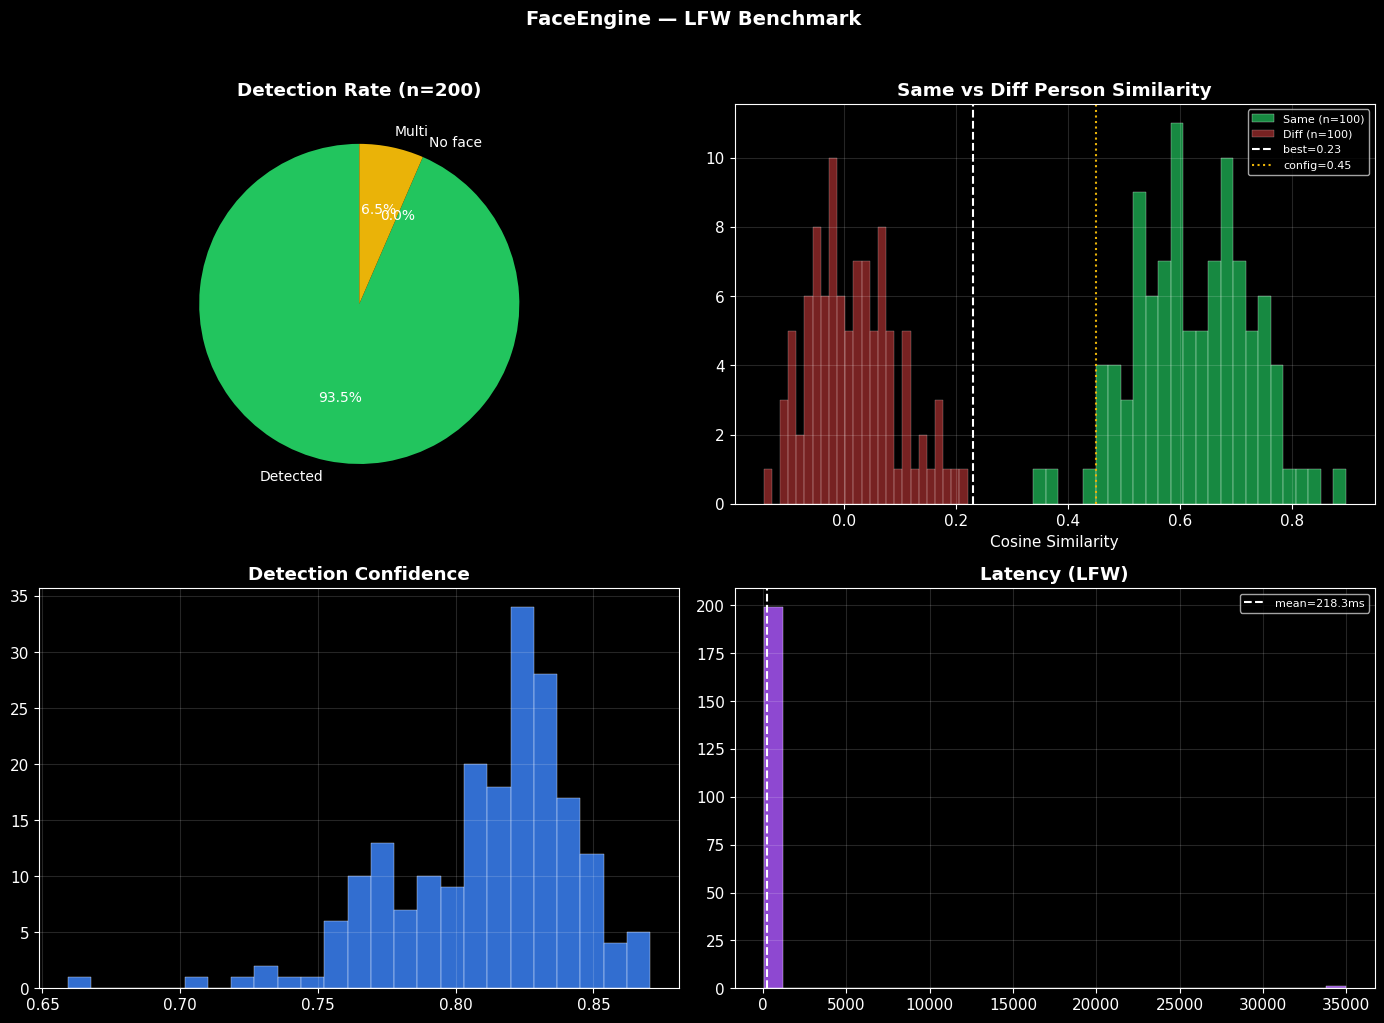

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Detection pie
axes[0,0].pie([face_acc['detected'],face_acc['no_face'],face_acc['multi']],
              labels=['Detected','No face','Multi'], colors=[C['green'],C['red'],C['yellow']],
              autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
axes[0,0].set_title(f'Detection Rate (n={tot})', fontweight='bold')

# 2) Same vs Diff similarity
axes[0,1].hist(same_sims, bins=25, color=C['green'], alpha=0.7,
               label=f'Same (n={len(same_sims)})', edgecolor='white', linewidth=0.3)
axes[0,1].hist(diff_sims, bins=25, color=C['red'], alpha=0.5,
               label=f'Diff (n={len(diff_sims)})', edgecolor='white', linewidth=0.3)
axes[0,1].axvline(best_thr, color='white', linestyle='--', label=f'best={best_thr:.2f}')
axes[0,1].axvline(0.45, color=C['yellow'], linestyle=':', label='config=0.45')
axes[0,1].set_title('Same vs Diff Person Similarity', fontweight='bold')
axes[0,1].set_xlabel('Cosine Similarity'); axes[0,1].legend(fontsize=8)

# 3) Confidence
if face_acc['confs']:
    axes[1,0].hist(face_acc['confs'], bins=25, color=C['blue'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[1,0].set_title('Detection Confidence', fontweight='bold')

# 4) Latency
if face_acc['times_ms']:
    t_arr = np.array(face_acc['times_ms'])
    axes[1,1].hist(t_arr, bins=30, color=C['purple'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[1,1].axvline(t_arr.mean(), color='white', linestyle='--', label=f'mean={t_arr.mean():.1f}ms')
    axes[1,1].set_title('Latency (LFW)', fontweight='bold'); axes[1,1].legend(fontsize=8)

plt.suptitle('FaceEngine — LFW Benchmark', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/bench_face.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. ParkingDB — pgvector (Real Embeddings from LFW)

In [21]:
from database import ParkingDB, DIM
import yaml

with open(str(PROJECT_DIR / 'config.yaml'), 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)
dcfg = cfg['database']
db = ParkingDB(host=dcfg['host'], port=dcfg['port'], dbname=dcfg['dbname'],
               user=dcfg['user'], password=dcfg['password'], max_cap=dcfg['max_capacity'])
print(f'DB stats: {db.stats()}')

# Collect real embeddings
print('Collecting LFW embeddings...')
real_embs = []
for p in random.sample(lfw_images, min(600, len(lfw_images))):
    img = cv2.imread(p)
    if img is None: continue
    faces = face_eng(img)
    if faces:
        real_embs.append(max(faces, key=lambda f:f['conf'])['embedding'])
    if len(real_embs) >= 500: break
print(f'Got {len(real_embs)} embeddings')

DB stats: {'current': 1, 'capacity': 500, 'pct': 0.2}
Got 500 embeddings


In [22]:
DB_SIZES = [10, 50, 100, 200, 500]
db_search_stats, db_insert_stats = [], []

for n in DB_SIZES:
    if n > len(real_embs):
        print(f'  Skip n={n}'); continue
    
    with db._conn() as conn:
        conn.cursor().execute("DELETE FROM active WHERE plate LIKE 'BM_%'")
    
    ids = []
    t0 = time.perf_counter()
    for i in range(n):
        r = db.entry(f'BM_{i:04d}', real_embs[i], 0.9, 0.8)
        if r > 0: ids.append(r)
    t_ins = (time.perf_counter()-t0)*1000
    db_insert_stats.append({'n':n, 'total_ms':t_ins, 'per_ms':t_ins/max(len(ids),1)})
    
    q = real_embs[min(n, len(real_embs)-1)]
    s = bench(lambda: db.match_exit(q, 0.3), n=min(N_BENCH,200), warmup=3, label=f'Search n={len(ids)}')
    db_search_stats.append(s)
    
    for rid in ids: db.exit(rid, 0.5)

print('\n=== Insert ===')
for s in db_insert_stats:
    print(f'  n={s["n"]:4d}  per_record={s["per_ms"]:.2f}ms')

  Search n=10                     avg=   9.17ms  p95=   9.43ms  fps= 109.1
  Search n=50                     avg=   9.62ms  p95=  10.42ms  fps= 103.9
  Search n=100                    avg=  10.94ms  p95=  11.47ms  fps=  91.4
  Search n=200                    avg=  12.69ms  p95=  13.47ms  fps=  78.8
  Search n=499                    avg=  19.02ms  p95=  20.33ms  fps=  52.6

=== Insert ===
  n=  10  per_record=7.97ms
  n=  50  per_record=6.90ms
  n= 100  per_record=7.11ms
  n= 200  per_record=7.27ms
  n= 500  per_record=7.15ms


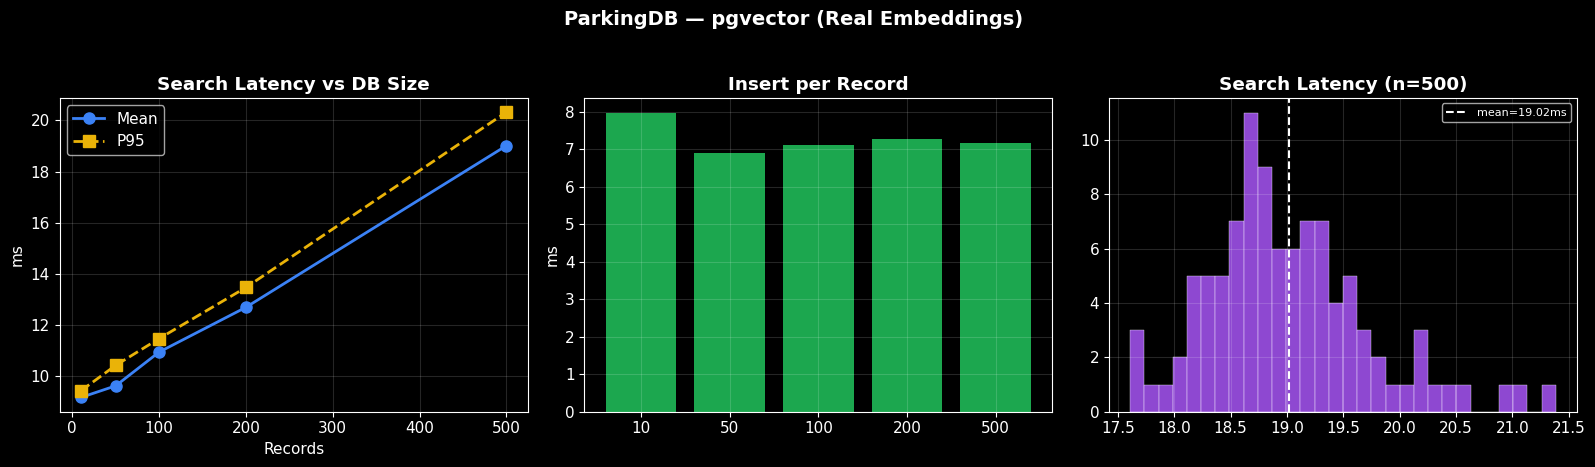

In [23]:
if db_search_stats:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    ns = [s['n'] for s in db_insert_stats]

    axes[0].plot(ns[:len(db_search_stats)], [s['mean'] for s in db_search_stats], 'o-',
                 color=C['blue'], label='Mean', linewidth=2, markersize=8)
    axes[0].plot(ns[:len(db_search_stats)], [s['p95'] for s in db_search_stats], 's--',
                 color=C['yellow'], label='P95', linewidth=2, markersize=8)
    axes[0].set_xlabel('Records'); axes[0].set_ylabel('ms')
    axes[0].set_title('Search Latency vs DB Size', fontweight='bold'); axes[0].legend()

    axes[1].bar(range(len(ns)), [s['per_ms'] for s in db_insert_stats],
                tick_label=[str(n) for n in ns], color=C['green'], alpha=0.85)
    axes[1].set_title('Insert per Record', fontweight='bold'); axes[1].set_ylabel('ms')

    last = db_search_stats[-1]
    axes[2].hist(last['raw'], bins=30, color=C['purple'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[2].axvline(last['mean'], color='white', linestyle='--', label=f'mean={last["mean"]:.2f}ms')
    axes[2].set_title(f'Search Latency (n={ns[-1]})', fontweight='bold'); axes[2].legend(fontsize=8)

    plt.suptitle('ParkingDB — pgvector (Real Embeddings)', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('/tmp/bench_db.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## 6. Full Pipeline Accuracy — Face + Plate paired samples

Đánh giá **toàn bộ pipeline entry → exit** bằng cách ghép cặp data val:

- **Face**: identity có >= 2 ảnh trong LFW → 1 ảnh làm *gallery* (entry), 1 ảnh làm *probe* (exit).
- **Plate**: ảnh trong OCR val split có text GT trong `paddle_format/0rec_gt.txt` → dùng làm biển số của xe.

**Luồng mô phỏng:**

1. **Entry**: OCR(plate crop) → `PlateValidator` → `FaceEngine`(gallery) → embedding → `db.entry(plate, emb)`.
2. **Exit**: `FaceEngine`(probe) → embedding → `db.match_exit(emb, face_threshold)` → plate verify bằng OCR lại.

**Metric báo cáo:**

- Entry success rate (OCR hợp lệ + face phát hiện + DB accept).
- Exit Top-1 identity accuracy (pgvector có tìm đúng xe đã vào không).
- Plate verification rate (OCR exit khớp plate entry sau normalize).
- Full pipeline success (tất cả các stage đều pass).
- Latency từng stage (entry vs exit).

> Lưu ý: OCR val set là crop biển số đã cắt sẵn. Plate detection đã đo riêng ở Section 1; section này kiểm tra khả năng phối hợp downstream OCR + Face + DB.

In [24]:
# ── Full Pipeline: Face + Plate paired evaluation ──
FACE_THR_FULL = float(cfg['recognition'].get('face_threshold', 0.45))
N_FULL_MAX = 455

# 1) Build face pairs (identity có >=2 ảnh) — seed cố định để reproducible
rng_full = random.Random(2026)
face_pairs_full = []
for name, imgs in multi.items():
    if len(imgs) < 2:
        continue
    g, p = rng_full.sample(imgs, 2)
    face_pairs_full.append((name, g, p))
rng_full.shuffle(face_pairs_full)

# 2) Build plate samples từ OCR val (có text GT)
plate_samples_full = []
if HAS_OCR:
    gt_map_full = load_ocr_text_gt_map(OCR_TEXT_GT)
    for s in load_ocr_samples(OCR_IMAGES_DIR, OCR_LABELS_DIR):
        key = Path(s['img_path']).name
        stem = Path(s['img_path']).stem
        gt = gt_map_full.get(key) or gt_map_full.get(stem)
        if gt:
            plate_samples_full.append({'img_path': s['img_path'], 'gt_text': gt})
rng_full.shuffle(plate_samples_full)

n_full = min(N_FULL_MAX, len(face_pairs_full), len(plate_samples_full))
print(f'Face pairs (>=2 imgs): {len(face_pairs_full)}')
print(f'Plate samples w/ GT  : {len(plate_samples_full)}')
print(f'→ Paired evaluated   : {n_full}')

full_result = None
if n_full == 0 or not HAS_OCR:
    print('⚠️  SKIP — thiếu data face (>=2 ảnh) hoặc plate OCR GT')
else:
    paired_full = list(zip(face_pairs_full[:n_full], plate_samples_full[:n_full]))

    # Dọn state cũ — kiểm tra record tồn đọng từ lần chạy trước
    with db._conn() as conn:
        cur = conn.cursor()
        cur.execute("SELECT COUNT(*) FROM active WHERE plate LIKE 'FULL_%'")
        leftover = cur.fetchone()[0]
        cur.execute("SELECT COUNT(*) FROM active")
        total_before = cur.fetchone()[0]
        cur.execute("DELETE FROM active WHERE plate LIKE 'FULL_%'")
    print(f'DB trước cleanup : {total_before} record tổng, {leftover} record FULL_ tồn đọng')
    if leftover:
        print(f'  ⚠️  Có {leftover} record từ lần chạy trước bị sót — đã xóa')
    else:
        print(f'  ✅ Không có record tồn đọng')

    # Reset stats cache từ actual DB count.
    # Section 4 (ParkingDB bench) dùng raw SQL DELETE nên không cập nhật
    # _stats_cache["current"] — nếu không reset thì db.entry() tưởng DB đầy.
    with db._stats_lock:
        db._stats_cache = db._query_stats()
    print(f'  Stats cache reset: current={db._stats_cache["current"]}, '
          f'capacity={db._stats_cache["capacity"]}')

    # Inspect records còn lại (pre-existing) — sẽ làm distractor khi exit match
    with db._conn() as conn:
        cur = conn.cursor()
        cur.execute("""
            SELECT split_part(plate, '_', 1) AS prefix, COUNT(*) AS cnt,
                   MIN(id) AS min_rid, MAX(id) AS max_rid
            FROM active
            GROUP BY prefix
            ORDER BY cnt DESC
        """)
        pre_rows = cur.fetchall()
    if pre_rows:
        print(f'\n  Pre-existing records (sẽ là distractor khi exit):')
        for prefix, cnt, mn, mx in pre_rows:
            print(f'    prefix={prefix!r:15s} count={cnt:3d}  rid range={mn}..{mx}')

    T = {k: [] for k in
         ['entry_ocr','entry_face','entry_db','entry_total',
          'exit_face','exit_db','exit_ocr','exit_total']}
    rows = []

    # ── Pass 1: ENTRY cho toàn bộ mẫu (xây active table) ──
    print(f'\n[1/2] Entry pass...')
    for i, ((name, g_path, p_path), psample) in enumerate(paired_full):
        row = {
            'i': i, 'identity': name, 'gt_text': psample['gt_text'],
            'plate_img': psample['img_path'], 'probe_img': p_path,
            'plate_entry': None, 'rid': None,
            'entry_ocr_valid': False, 'entry_face_ok': False, 'entry_db_ok': False,
            'exit_face_ok': False, 'exit_matched': False, 'exit_correct': False,
            'plate_verified': False, 'match_sim': None, 'matched_rid': None,
            # Drop reason + chi tiết debug từng sample
            'drop_stage': None, 'drop_detail': None,
            'ocr_raw': None, 'n_faces_entry': None, 'entry_rid_code': None,
            'n_faces_exit': None,
            # Chẩn đoán wrong-match: lưu embedding gallery để tính genuine_sim ở exit pass
            'gallery_emb': None, 'top3': None, 'genuine_sim': None,
        }

        plate_img = cv2.imread(psample['img_path'])
        g_img = cv2.imread(g_path)
        if plate_img is None or g_img is None:
            rows.append(row); continue

        t_entry = time.perf_counter()
        t0 = time.perf_counter()
        raw, ocr_conf = plate_ocr(plate_img)
        T['entry_ocr'].append((time.perf_counter()-t0)*1000)

        row['ocr_raw'] = raw
        plate_entry = validator(raw)
        if not plate_entry:
            row['drop_stage'] = 'entry_ocr_invalid'
            row['drop_detail'] = f'raw={raw!r} gt={psample["gt_text"]!r}'
            rows.append(row); continue
        row['entry_ocr_valid'] = True
        row['plate_entry'] = plate_entry

        t0 = time.perf_counter()
        faces_g = face_eng(g_img)
        T['entry_face'].append((time.perf_counter()-t0)*1000)
        row['n_faces_entry'] = len(faces_g)
        if len(faces_g) != 1:
            row['drop_stage'] = 'entry_face'
            row['drop_detail'] = (
                'no_face (detector miss)' if len(faces_g) == 0
                else f'multi_face (n={len(faces_g)}, ảnh có nhiều người)')
            rows.append(row); continue
        row['entry_face_ok'] = True
        face_g = faces_g[0]
        row['gallery_emb'] = face_g['embedding']

        # Plate key bao gồm index để tránh trùng plate giữa các identity
        plate_key = f"FULL_{i:03d}|{plate_entry}"
        t0 = time.perf_counter()
        rid = db.entry(plate_key, face_g['embedding'],
                       float(ocr_conf), float(face_g['conf']))
        T['entry_db'].append((time.perf_counter()-t0)*1000)
        T['entry_total'].append((time.perf_counter()-t_entry)*1000)
        row['entry_rid_code'] = int(rid)
        if rid > 0:
            row['entry_db_ok'] = True
            row['rid'] = rid
        else:
            row['drop_stage'] = 'entry_db'
            row['drop_detail'] = (
                'db_full (rid=-1)' if rid == -1
                else f'duplicate_plate (rid=-2, plate={plate_key!r})' if rid == -2
                else f'db_error (rid={rid})')
        rows.append(row)

    n_enrolled = sum(1 for r in rows if r['entry_db_ok'])
    print(f'  Enrolled in DB: {n_enrolled}/{n_full}')

    # ── Pass 2: EXIT mirror main.py:process_exit (plate-first → manual face sim) ──
    # Production flow: find_by_plate(plate) → cosine thủ công np.dot(probe, record.emb)
    # Không dùng match_exit() (vector search IVFFlat) vì production đã bỏ nhánh đó.
    print(f'[2/2] Exit pass (plate-first, mirror process_exit)...')
    for row in rows:
        if not row['entry_db_ok']:
            continue
        probe = cv2.imread(row['probe_img'])
        plate_img = cv2.imread(row['plate_img'])
        if probe is None or plate_img is None:
            continue

        t_exit = time.perf_counter()

        # ── Face detect + embedding probe ──
        t0 = time.perf_counter()
        faces_p = face_eng(probe)
        T['exit_face'].append((time.perf_counter()-t0)*1000)
        row['n_faces_exit'] = len(faces_p)
        if not faces_p:
            row['drop_stage'] = 'exit_face_none'
            row['drop_detail'] = 'probe không detect được face'
            T['exit_total'].append((time.perf_counter()-t_exit)*1000)
            continue
        row['exit_face_ok'] = True
        face_p = max(faces_p, key=lambda f: f['conf'])

        # Genuine sim (chẩn đoán): probe vs gallery embedding của chính identity
        if row['gallery_emb'] is not None:
            row['genuine_sim'] = float(np.dot(face_p['embedding'], row['gallery_emb']))

        # ── OCR plate ở exit ──
        t0 = time.perf_counter()
        raw_exit, _ = plate_ocr(plate_img)
        T['exit_ocr'].append((time.perf_counter()-t0)*1000)
        plate_exit = validator(raw_exit)
        if not plate_exit:
            row['drop_stage'] = 'exit_ocr_invalid'
            row['drop_detail'] = f'raw={raw_exit!r} (validator reject at exit)'
            T['exit_total'].append((time.perf_counter()-t_exit)*1000)
            continue

        # ── DB lookup theo plate (mirror find_by_plate).
        # Plate key benchmark có prefix 'FULL_xxx|' để tránh duplicate khi enroll
        # → dùng LIKE '%|{plate_exit}' để lookup theo hậu tố plate thật. ──
        t0 = time.perf_counter()
        with db._conn() as conn:
            cur = conn.cursor()
            cur.execute(
                "SELECT id, plate, embedding FROM active WHERE plate LIKE %s",
                (f'%|{plate_exit}',))
            candidates = cur.fetchall()
        T['exit_db'].append((time.perf_counter()-t0)*1000)

        if not candidates:
            row['drop_stage'] = 'exit_plate_not_found'
            row['drop_detail'] = (
                f'plate_exit={plate_exit!r} không khớp record nào trong active '
                f'(OCR entry={row["plate_entry"]!r})')
            T['exit_total'].append((time.perf_counter()-t_exit)*1000)
            continue

        # Nếu plate text trùng giữa nhiều record, pick theo cosine sim cao nhất
        # — giống tinh thần '1 xe/plate' của production.
        cand_rows = []
        best_rid, best_sim, best_plate_db = None, -1.0, None
        for rid_db, plate_db, emb_raw in candidates:
            emb_db = np.array(emb_raw, dtype=np.float32)
            sim = float(np.dot(face_p['embedding'], emb_db))
            cand_rows.append((rid_db, plate_db, sim))
            if sim > best_sim:
                best_sim, best_rid, best_plate_db = sim, rid_db, plate_db

        cand_rows.sort(key=lambda x: -x[2])
        row['top3'] = cand_rows[:3]         # chỉ lưu top-3 để debug
        row['match_sim'] = best_sim
        row['matched_rid'] = best_rid

        if best_sim < FACE_THR_FULL:
            row['drop_stage'] = 'exit_sim_below_thr'
            row['drop_detail'] = (
                f'plate matched rid={best_rid} nhưng face sim={best_sim:.3f} '
                f'< thr={FACE_THR_FULL}')
        elif best_rid != row['rid']:
            row['exit_matched'] = True
            row['drop_stage'] = 'exit_wrong_id'
            row['drop_detail'] = (
                f'plate duplicate → matched rid={best_rid} (sim={best_sim:.3f}) '
                f'thay vì rid={row["rid"]}')
        else:
            row['exit_matched'] = True
            row['exit_correct'] = True
            row['plate_verified'] = True    # plate là key lookup → verified by construction

        T['exit_total'].append((time.perf_counter()-t_exit)*1000)

    # Dọn state
    with db._conn() as conn:
        conn.cursor().execute("DELETE FROM active WHERE plate LIKE 'FULL_%'")

    # ── Tổng hợp metric ──
    def pct(num, den):
        return 100 * num / max(den, 1)

    n_entry_ok = sum(1 for r in rows if r['entry_db_ok'])
    n_exit_face = sum(1 for r in rows if r['exit_face_ok'])
    n_exit_match = sum(1 for r in rows if r['exit_matched'])
    n_exit_correct = sum(1 for r in rows if r['exit_correct'])
    n_plate_verified = sum(1 for r in rows if r['plate_verified'])
    n_full_success = sum(
        1 for r in rows
        if r['entry_db_ok'] and r['exit_correct'] and r['plate_verified']
    )
    n_wrong_match = sum(
        1 for r in rows
        if r['exit_matched'] and not r['exit_correct']
    )

    full_result = {
        'n': n_full,
        'face_threshold': FACE_THR_FULL,
        'counts': {
            'entry_ocr_valid': sum(1 for r in rows if r['entry_ocr_valid']),
            'entry_face_ok': sum(1 for r in rows if r['entry_face_ok']),
            'entry_db_ok': n_entry_ok,
            'exit_face_ok': n_exit_face,
            'exit_matched': n_exit_match,
            'exit_correct': n_exit_correct,
            'exit_wrong_match': n_wrong_match,
            'plate_verified': n_plate_verified,
            'full_success': n_full_success,
        },
        'T': T,
        'rows': rows,
    }

    c = full_result['counts']
    print(f'\n=== Full Pipeline Accuracy (n={n_full}, face_thr={FACE_THR_FULL}) ===')
    print(f'  Entry OCR valid     : {c["entry_ocr_valid"]:3d}/{n_full} ({pct(c["entry_ocr_valid"],n_full):5.1f}%)')
    print(f'  Entry face detected : {c["entry_face_ok"]:3d}/{n_full} ({pct(c["entry_face_ok"],n_full):5.1f}%)')
    print(f'  Entry DB accepted   : {c["entry_db_ok"]:3d}/{n_full} ({pct(c["entry_db_ok"],n_full):5.1f}%)')
    en = max(n_entry_ok, 1)
    print(f'  Exit face detected  : {c["exit_face_ok"]:3d}/{n_entry_ok} ({pct(c["exit_face_ok"],en):5.1f}%)')
    print(f'  Exit matched any    : {c["exit_matched"]:3d}/{n_entry_ok} ({pct(c["exit_matched"],en):5.1f}%)')
    print(f'  Exit correct ID     : {c["exit_correct"]:3d}/{n_entry_ok} ({pct(c["exit_correct"],en):5.1f}%)')
    print(f'  Exit wrong match    : {c["exit_wrong_match"]:3d}/{n_entry_ok} ({pct(c["exit_wrong_match"],en):5.1f}%)')
    print(f'  Plate verified      : {c["plate_verified"]:3d}/{n_entry_ok} ({pct(c["plate_verified"],en):5.1f}%)')
    print(f'  FULL pipeline OK    : {c["full_success"]:3d}/{n_full} ({pct(c["full_success"],n_full):5.1f}%)')

    print('\n=== Full Pipeline Latency ===')
    print(f'  {"Stage":16s} {"Mean":>8s} {"P95":>8s} {"N":>6s}')
    print('  ' + '-'*42)
    for k in ['entry_ocr','entry_face','entry_db','entry_total',
              'exit_face','exit_db','exit_ocr','exit_total']:
        v = T[k]
        if not v:
            continue
        a = np.array(v)
        print(f'  {k:16s} {a.mean():7.1f}ms {np.percentile(a,95):7.1f}ms {len(v):6d}')

    # ── Drop reason breakdown + chi tiết per-sample ──
    from collections import Counter as _Counter
    drop_counter = _Counter(r['drop_stage'] for r in rows if r['drop_stage'])
    if drop_counter:
        print(f'\n=== Drop reasons (per-stage counts) ===')
        for stage, cnt in drop_counter.most_common():
            print(f'  {stage:20s} : {cnt}')

    MAX_PER_STAGE = 40
    by_stage = {}
    for r in rows:
        if r['drop_stage']:
            by_stage.setdefault(r['drop_stage'], []).append(r)
    for stage, lst in by_stage.items():
        print(f'\n--- {stage} (showing {min(MAX_PER_STAGE, len(lst))}/{len(lst)}) ---')
        for r in lst[:MAX_PER_STAGE]:
            img = Path(r['plate_img']).name
            probe = Path(r['probe_img']).name if r['probe_img'] else '-'
            print(f'  [i={r["i"]:3d}] id={r["identity"]:25s} '
                  f'plate={img} probe={probe}')
            print(f'         → {r["drop_detail"]}')

    # Xuất CSV đầy đủ để soi trên Excel/CSV viewer
    import csv as _csv
    drop_csv = Path('/home/somethink/parking_system/bench_full_pipeline_drops.csv')
    fields = ['i','identity','drop_stage','drop_detail','gt_text','plate_entry',
              'ocr_raw','n_faces_entry','entry_rid_code','n_faces_exit',
              'rid','matched_rid','match_sim','plate_img','probe_img']
    with drop_csv.open('w', newline='', encoding='utf-8') as f:
        w = _csv.DictWriter(f, fieldnames=fields, extrasaction='ignore')
        w.writeheader()
        w.writerows(rows)
    print(f'\nPer-sample detail CSV: {drop_csv}')

    # ── Chẩn đoán exit_no_match: xem phân bố top-1 sim ──
    # Sample plate tìm được nhưng face sim < thr
    below_thr_rows = [r for r in rows if r['drop_stage'] == 'exit_sim_below_thr']
    if below_thr_rows:
        sims_nm = np.array([r['match_sim'] for r in below_thr_rows])
        correct_rid = sum(1 for r in below_thr_rows if r['matched_rid'] == r['rid'])
        print(f'\n=== exit_sim_below_thr diagnostic (n={len(below_thr_rows)}) ===')
        print(f'  Phân bố face sim (sau khi plate đã match):')
        print(f'    min   : {sims_nm.min():.3f}')
        print(f'    p25   : {np.percentile(sims_nm, 25):.3f}')
        print(f'    median: {np.median(sims_nm):.3f}')
        print(f'    p75   : {np.percentile(sims_nm, 75):.3f}')
        print(f'    max   : {sims_nm.max():.3f}')
        print(f'  face_threshold hiện tại: {FACE_THR_FULL}')
        print(f'  Plate khớp đúng rid                      : '
              f'{correct_rid}/{len(below_thr_rows)} '
              f'({100*correct_rid/len(below_thr_rows):.1f}%)')
        print(f'  Plate khớp sai rid (duplicate plate text) : '
              f'{len(below_thr_rows)-correct_rid}/{len(below_thr_rows)}')

        print(f'\n  Nếu hạ threshold thì sẽ match thêm bao nhiêu sample (plate đúng rid):')
        for thr in [0.55, 0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
            would_match = sum(1 for r in below_thr_rows
                              if r['match_sim'] >= thr and r['matched_rid'] == r['rid'])
            would_wrong = sum(1 for r in below_thr_rows
                              if r['match_sim'] >= thr and r['matched_rid'] != r['rid'])
            print(f'    thr={thr:.2f} → +{would_match} correct, +{would_wrong} wrong_id')

    # Sample OCR fail riêng ở exit (nhưng entry pass được)
    exit_ocr_fail = [r for r in rows if r['drop_stage'] == 'exit_ocr_invalid']
    if exit_ocr_fail:
        print(f'\n=== exit_ocr_invalid: {len(exit_ocr_fail)} sample ===')
        print(f'  (OCR cùng ảnh ở entry pass → vì sao fail ở exit?)')
        for r in exit_ocr_fail[:5]:
            print(f'    [i={r["i"]:3d}] entry_plate={r["plate_entry"]!r} '
                  f'{r["drop_detail"]}')

    # Sample plate OCR valid nhưng không tìm thấy trong DB (OCR lệch so với entry)
    not_found = [r for r in rows if r['drop_stage'] == 'exit_plate_not_found']
    if not_found:
        print(f'\n=== exit_plate_not_found: {len(not_found)} sample ===')
        print(f'  (OCR ở exit cho plate khác với entry → OCR không deterministic)')
        for r in not_found[:5]:
            print(f'    [i={r["i"]:3d}] entry_plate={r["plate_entry"]!r} '
                  f'{r["drop_detail"]}')

    wrong = [r for r in rows if r['exit_matched'] and not r['exit_correct']]
    if wrong:
        print(f'\n=== exit_wrong_id chi tiết — top-3 + genuine sim ===')
        for r in sorted(wrong, key=lambda r: -(r['match_sim'] or 0)):
            gs = r['genuine_sim']
            gs_str = f'{gs:.3f}' if gs is not None else 'N/A'
            print(f'\n  [i={r["i"]:3d}] {r["identity"]} '
                  f'(correct rid={r["rid"]}, genuine_sim={gs_str})')
            print(f'    probe: {Path(r["probe_img"]).name}')
            top3 = r.get('top3') or []
            for rank, (rid, plate, sim) in enumerate(top3, start=1):
                tag = '← ĐÚNG' if rid == r['rid'] else ''
                # Đánh dấu record pre-existing (không có prefix FULL_) để thấy distractor
                pre_tag = '' if str(plate).startswith('FULL_') else '[PRE-EXISTING]'
                print(f'    top{rank}: rid={rid:5d}  sim={sim:.3f}  '
                      f'plate={plate!r:40s} {pre_tag} {tag}')
            if gs is not None and r['match_sim'] is not None:
                gap = r['match_sim'] - gs
                print(f'    → best candidate sim - genuine sim = {gap:+.3f} '
                      f'({"plate duplicate hút về imposter" if gap > 0 else "genuine record bị cover bởi plate khác"})')

        # Breakdown: bao nhiêu wrong match là do pre-existing record?
        n_pre_wrong = sum(1 for r in wrong
                          if r.get('top3') and not str(r['top3'][0][1]).startswith('FULL_'))
        n_full_wrong = len(wrong) - n_pre_wrong
        print(f'\n  → Wrong match bị gây ra bởi:')
        print(f'    Pre-existing records (không phải FULL_): {n_pre_wrong}/{len(wrong)}')
        print(f'    Record trong lần chạy này (FULL_)      : {n_full_wrong}/{len(wrong)}')

Face pairs (>=2 imgs): 1391
Plate samples w/ GT  : 450
→ Paired evaluated   : 450
DB trước cleanup : 1 record tổng, 0 record FULL_ tồn đọng
  ✅ Không có record tồn đọng
  Stats cache reset: current=1, capacity=500

  Pre-existing records (sẽ là distractor khi exit):
    prefix='99B1-306.89'   count=  1  rid range=2..2

[1/2] Entry pass...
  Enrolled in DB: 444/450
[2/2] Exit pass (plate-first, mirror process_exit)...

=== Full Pipeline Accuracy (n=450, face_thr=0.3) ===
  Entry OCR valid     : 444/450 ( 98.7%)
  Entry face detected : 444/450 ( 98.7%)
  Entry DB accepted   : 444/450 ( 98.7%)
  Exit face detected  : 444/444 (100.0%)
  Exit matched any    : 444/444 (100.0%)
  Exit correct ID     : 444/444 (100.0%)
  Exit wrong match    :   0/444 (  0.0%)
  Plate verified      : 444/444 (100.0%)
  FULL pipeline OK    : 444/450 ( 98.7%)

=== Full Pipeline Latency ===
  Stage                Mean      P95      N
  ------------------------------------------
  entry_ocr           21.7ms    22.9

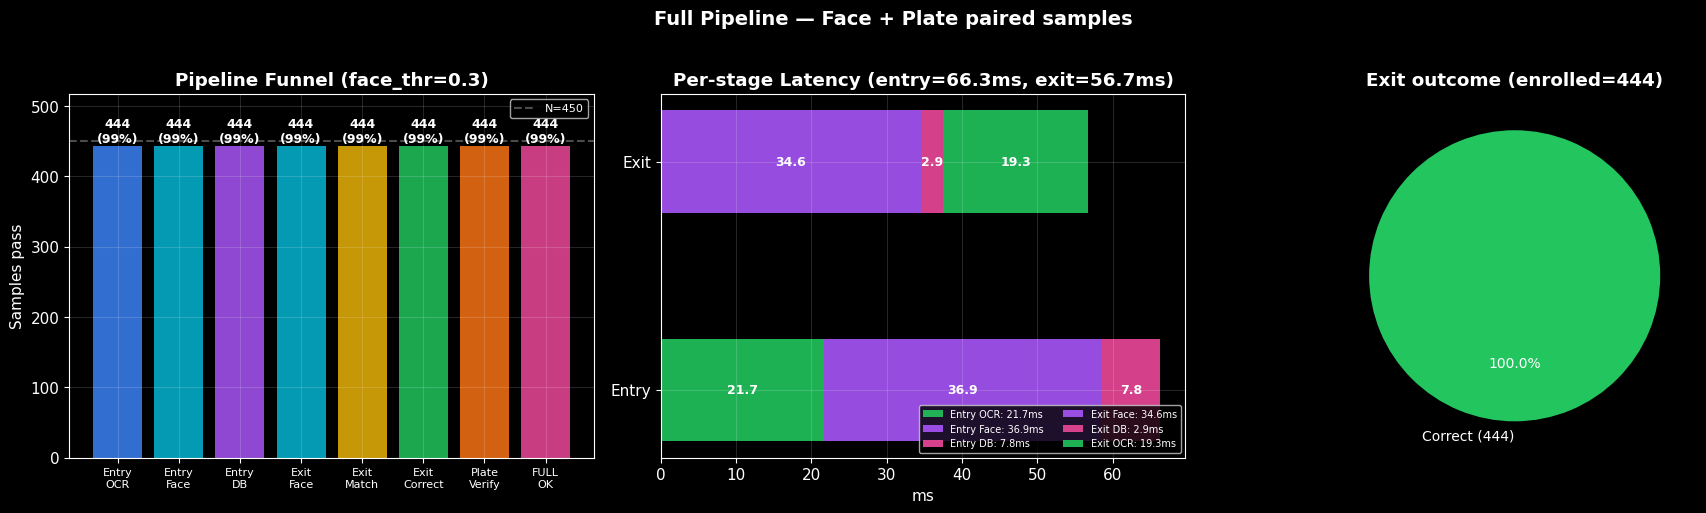

In [25]:
if full_result is not None:
    c = full_result['counts']; T = full_result['T']; n = full_result['n']
    n_enrolled = max(c['entry_db_ok'], 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (1) Funnel: tỷ lệ pass qua các stage
    stages = ['Entry\nOCR', 'Entry\nFace', 'Entry\nDB',
              'Exit\nFace', 'Exit\nMatch', 'Exit\nCorrect',
              'Plate\nVerify', 'FULL\nOK']
    vals = [c['entry_ocr_valid'], c['entry_face_ok'], c['entry_db_ok'],
            c['exit_face_ok'], c['exit_matched'], c['exit_correct'],
            c['plate_verified'], c['full_success']]
    cols = [C['blue'], C['cyan'], C['purple'],
            C['cyan'], C['yellow'], C['green'],
            C['orange'], C['pink']]
    bars = axes[0].bar(stages, vals, color=cols, alpha=0.85)
    for b, v in zip(bars, vals):
        pct_v = 100 * v / n if n else 0
        axes[0].text(b.get_x() + b.get_width()/2, v + n*0.01,
                     f'{v}\n({pct_v:.0f}%)', ha='center', fontsize=9, fontweight='bold')
    axes[0].axhline(n, color='white', linestyle='--', alpha=0.3, label=f'N={n}')
    axes[0].set_ylabel('Samples pass'); axes[0].set_ylim(0, n * 1.15)
    axes[0].set_title(f'Pipeline Funnel (face_thr={full_result["face_threshold"]})',
                      fontweight='bold')
    axes[0].tick_params(axis='x', labelsize=8)
    axes[0].legend(fontsize=8)

    # (2) Latency stack (entry vs exit)
    entry_keys = ['entry_ocr','entry_face','entry_db']
    exit_keys  = ['exit_face','exit_db','exit_ocr']
    entry_means = [np.mean(T[k]) if T[k] else 0 for k in entry_keys]
    exit_means  = [np.mean(T[k]) if T[k] else 0 for k in exit_keys]
    entry_cols = [C['green'], C['purple'], C['pink']]
    exit_cols  = [C['purple'], C['pink'], C['green']]

    left = 0
    for v, name, co in zip(entry_means, ['OCR','Face','DB'], entry_cols):
        axes[1].barh(0, v, left=left, color=co, height=0.45,
                     label=f'Entry {name}: {v:.1f}ms', alpha=0.9)
        if v > 1:
            axes[1].text(left + v/2, 0, f'{v:.1f}', ha='center', va='center',
                         fontsize=9, fontweight='bold')
        left += v
    left = 0
    for v, name, co in zip(exit_means, ['Face','DB','OCR'], exit_cols):
        axes[1].barh(1, v, left=left, color=co, height=0.45,
                     label=f'Exit {name}: {v:.1f}ms', alpha=0.9)
        if v > 1:
            axes[1].text(left + v/2, 1, f'{v:.1f}', ha='center', va='center',
                         fontsize=9, fontweight='bold')
        left += v
    axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['Entry', 'Exit'])
    axes[1].set_xlabel('ms')
    axes[1].set_title(f'Per-stage Latency (entry={sum(entry_means):.1f}ms, exit={sum(exit_means):.1f}ms)',
                      fontweight='bold')
    axes[1].legend(fontsize=7, loc='lower right', ncol=2)

    # (3) Exit outcome pie
    correct = c['exit_correct']
    wrong = c['exit_wrong_match']
    no_match = c['exit_face_ok'] - c['exit_matched']
    no_face = c['entry_db_ok'] - c['exit_face_ok']
    labels = [f'Correct ({correct})', f'Wrong match ({wrong})',
              f'No match ({no_match})', f'No face ({no_face})']
    sizes = [correct, wrong, no_match, no_face]
    colors = [C['green'], C['red'], C['yellow'], C['orange']]
    nz = [(l, s, c_) for l, s, c_ in zip(labels, sizes, colors) if s > 0]
    if nz:
        nl, ns, nc = zip(*nz)
        axes[2].pie(ns, labels=nl, colors=nc, autopct='%1.1f%%',
                    startangle=90, textprops={'fontsize': 10})
    axes[2].set_title(f'Exit outcome (enrolled={n_enrolled})', fontweight='bold')

    plt.suptitle('Full Pipeline — Face + Plate paired samples',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/tmp/bench_full_pipeline.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  full_result is None — không có data để vẽ')